#  Sprint 1: EDA
---

# Table of Contents
---

1. [Introduction](#Introduction)
2. [Loading Libraries](#Loading-Libraries)
3. [Data Set Loading](#Data-Set-Loading)
4. [EDA](#eda)
    - [Feature Interpretation and Distribution Summary](#Feature-Interpretation-and-Distribution-Summary)  
    - [Correlation Matrix](#Correlation-Matrix)
5. [Next Steps: Pre-Processing](#Next-Steps-Pre-Processing)

## Introduction
---


In this notebook, we will be taking a look at the data we have prepared and cleaned in the previous notebook. We will be attempting to draw insights from the EDA to direct our feature engineering, feature selection and modelling in the next notebooks.

# Loading Libraries
---

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from warnings import filterwarnings
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# Data Set Loading <a class="anchor" id="loading the cleaned-and combined power and weather dataset"></a>
---
 Loading the cleaned-and combined power and weather dataset

In [9]:
file_path = r"C:\Users\karni\OneDrive\Desktop\GitHub\BrainStation_CapstoneProject\data\power_weather.csv"
power_df_clean = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')
power_df_clean.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,cloudcover,windspeed_10m,windgusts_10m,winddirection_10m,shortwave_radiation,direct_radiation,diffuse_radiation
Datetime,,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,7.120,94.200,6.240,4.100,1012.400,100.0,14.280,31.100,329.400,8.000,0.0,8.000
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,7.108,94.167,6.225,4.092,1012.417,100.0,14.242,31.075,329.417,7.833,0.0,7.833
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,7.097,94.133,6.210,4.083,1012.433,100.0,14.203,31.050,329.433,7.667,0.0,7.667
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,7.085,94.100,6.195,4.075,1012.450,100.0,14.165,31.025,329.450,7.500,0.0,7.500
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,7.073,94.067,6.180,4.067,1012.467,100.0,14.127,31.000,329.467,7.333,0.0,7.333


In [10]:
# Making sure the data is loaded correctly by checking the end date
power_df_clean.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,cloudcover,windspeed_10m,windgusts_10m,winddirection_10m,shortwave_radiation,direct_radiation,diffuse_radiation
Datetime,,,,,,,,,,,,,,,,,,,
2010-11-26 20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0,-1.163,90.6,-2.523,-4.763,994.707,37.4,7.480,12.950,215.267,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0,-1.182,90.8,-2.512,-4.782,994.703,37.7,7.490,12.975,215.133,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0,-1.200,91.0,-2.500,-4.800,994.700,38.0,7.500,13.000,215.000,0.0,0.0,0.0
2010-11-26 21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0,-1.202,91.0,-2.502,-4.803,994.695,38.6,7.508,13.000,214.867,0.0,0.0,0.0
2010-11-26 21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0,-1.203,91.0,-2.503,-4.807,994.690,39.2,7.517,13.000,214.733,0.0,0.0,0.0


In [11]:
#Checking that data types are correctly loaded
power_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049280 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   temperature_2m         float64
 8   relative_humidity_2m   float64
 9   dew_point_2m           float64
 10  apparent_temperature   float64
 11  surface_pressure       float64
 12  cloudcover             float64
 13  windspeed_10m          float64
 14  windgusts_10m          float64
 15  winddirection_10m      float64
 16  shortwave_radiation    float64
 17  direct_radiation       float64
 18  diffuse_radiation      float64
dtypes: float64(19)
memory usage: 312.7 MB


There are 20 numerical columns, as we had saved those from the previous Notebook

# EDA <a class="anchor" id="eda"></a>
---

In [12]:
#Lets take a look at the statistical properties of the numerical columns
power_df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000
temperature_2m,2049280.0,11.197882,6.947969,-10.400,6.197,11.258,16.250,34.800
relative_humidity_2m,2049280.0,76.620090,15.182177,23.000,66.167,79.650,89.233,100.000
dew_point_2m,2049280.0,6.848154,5.536301,-14.500,3.257,7.323,10.957,21.300


Here’s a summary of the range of values for each feature in your dataset (from the table):

Global_active_power: 0.076 to 11.122 kW

Global_reactive_power: 0.000 to 1.390 kW

Voltage: 223.200 to 254.150 V

Global_intensity: 0.200 to 48.400 A

Sub_metering_1: 0.000 to 88.000 Wh

Sub_metering_2: 0.000 to 80.000 Wh

Sub_metering_3: 0.000 to 31.000 Wh

temperature_2m: -10.400 to 34.800 °C

relative_humidity_2m: 23.000 to 100.000 %

dew_point_2m: -14.500 to 21.300 °C

apparent_temperature: -15.100 to 35.000 °C

surface_pressure: 959.200 to 1031.700 hPa

cloudcover: 0.000 to 100.000 %

windspeed_10m: 0.000 to 51.700 m/s

windgusts_10m: 2.200 to 99.000 m/s

winddirection_10m: 1.000 to 360.000 °

shortwave_radiation: 0.000 to 908.000 W/m²

direct_radiation: 0.000 to 779.000 W/m²

diffuse_radiation: 0.000 to 417.000 W/m²

In [13]:
list_features = list(power_df_clean.select_dtypes(include=['float64']).columns)
list_features 

['Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'temperature_2m',
 'relative_humidity_2m',
 'dew_point_2m',
 'apparent_temperature',
 'surface_pressure',
 'cloudcover',
 'windspeed_10m',
 'windgusts_10m',
 'winddirection_10m',
 'shortwave_radiation',
 'direct_radiation',
 'diffuse_radiation']

We will create distribution plots for all numerical features to understand their distributions and identify any potential outliers.

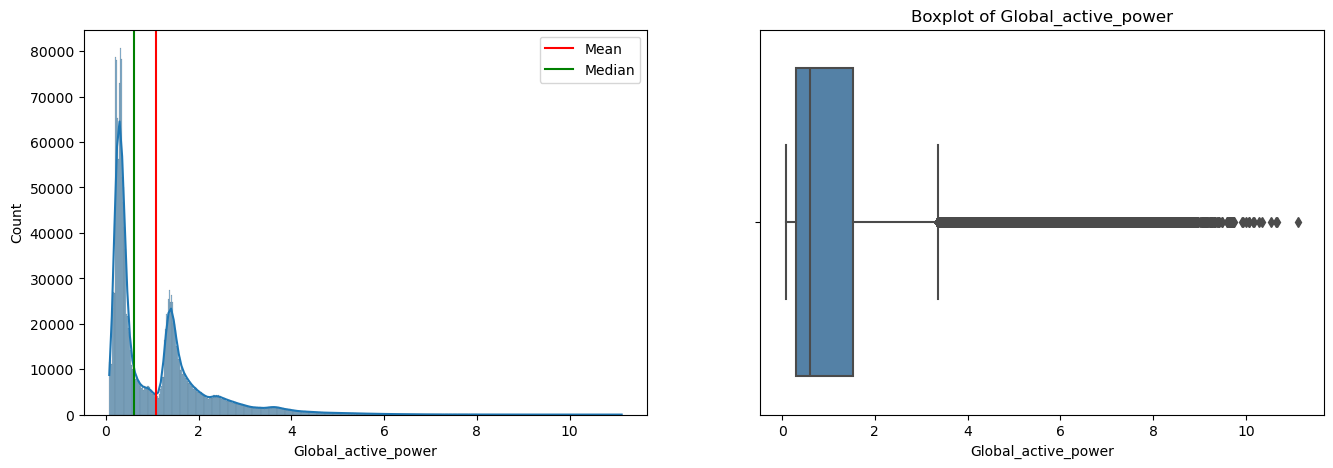

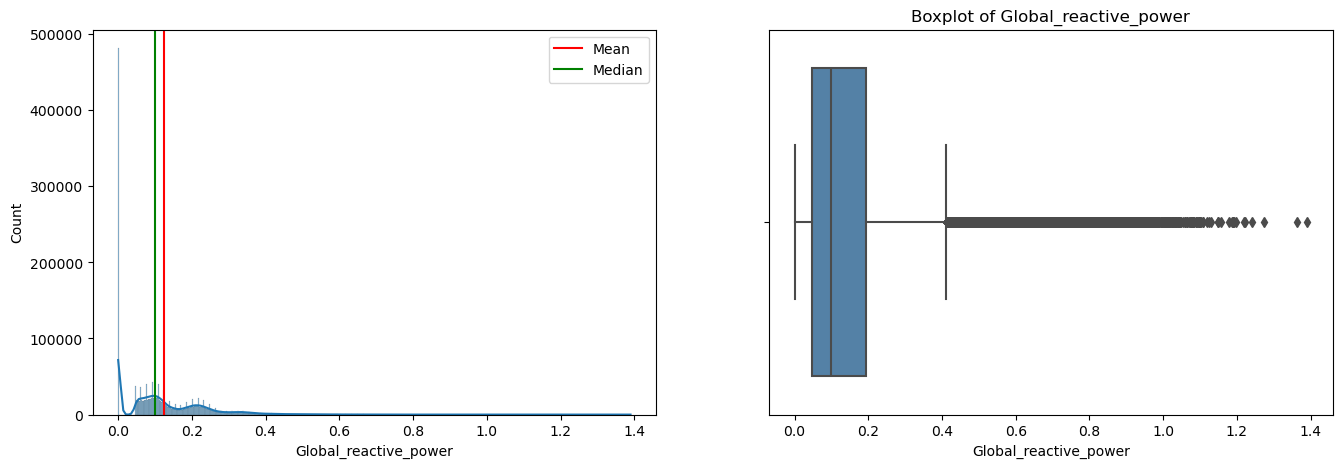

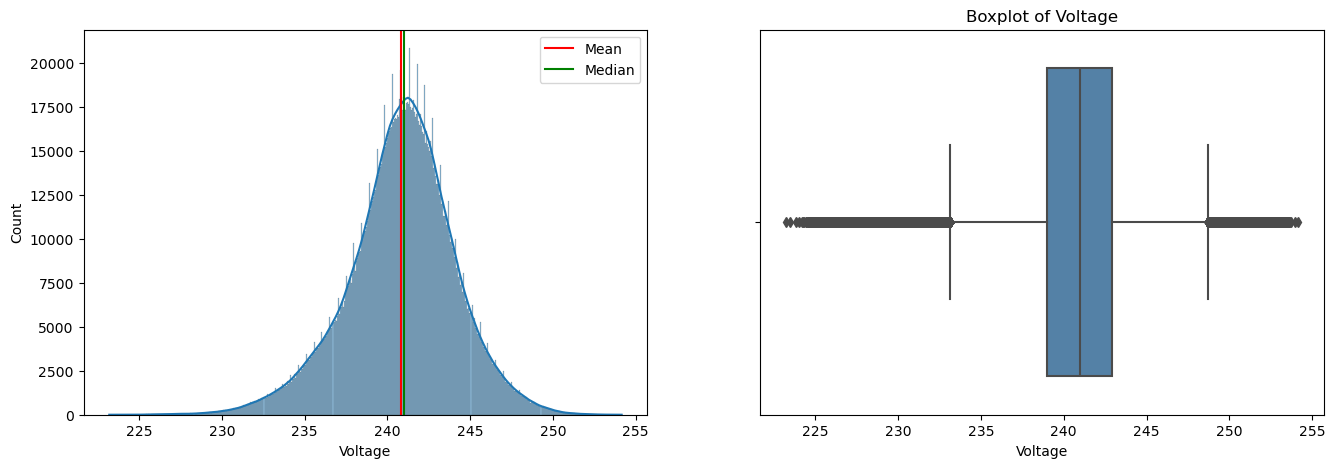

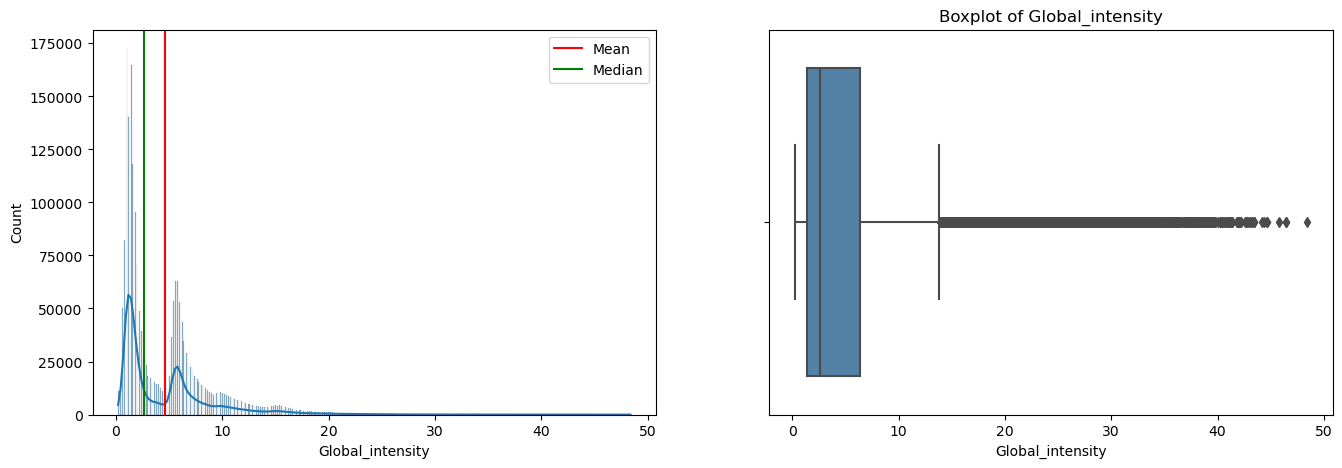

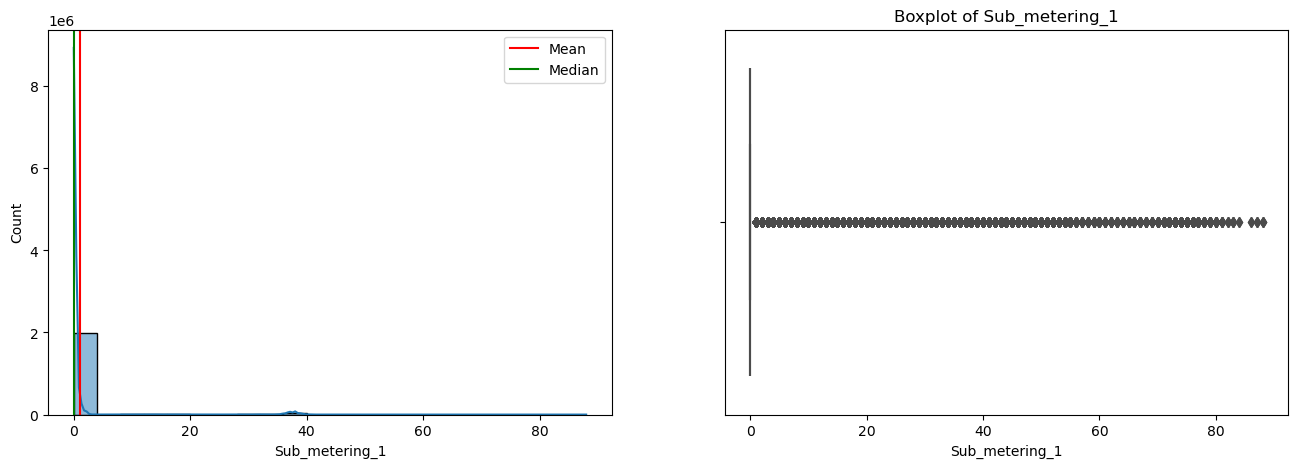

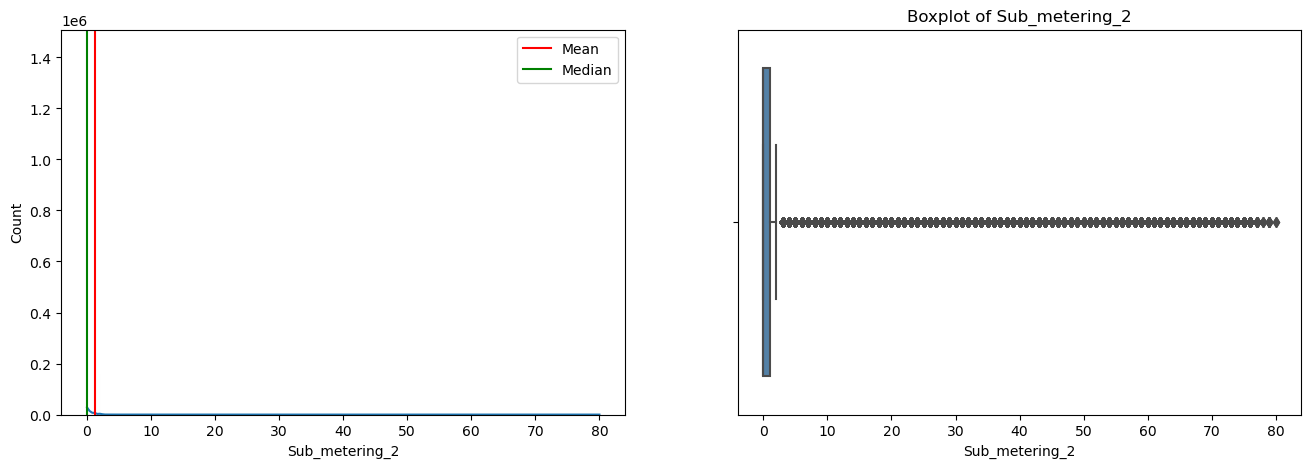

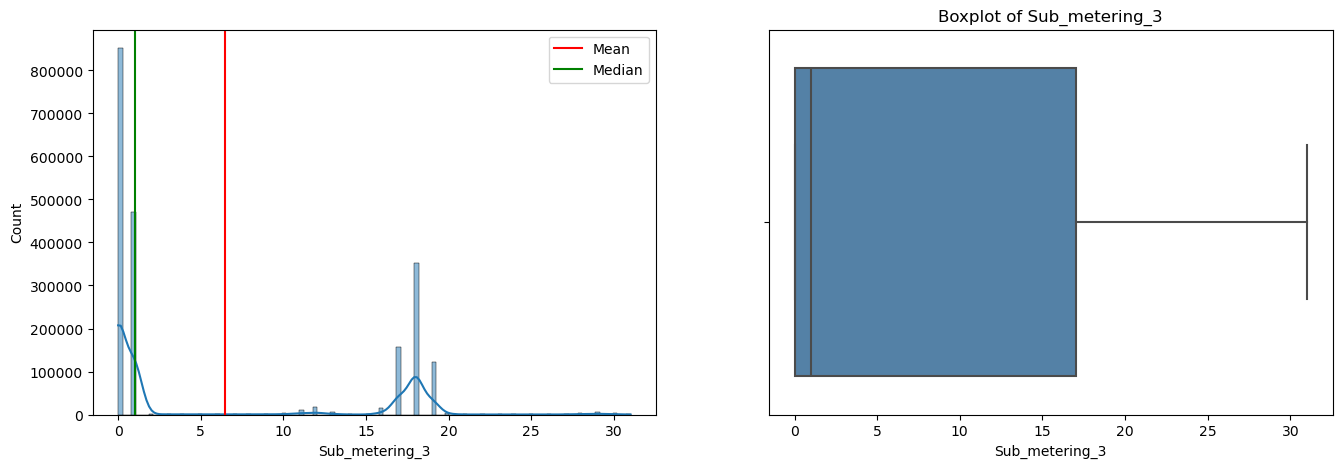

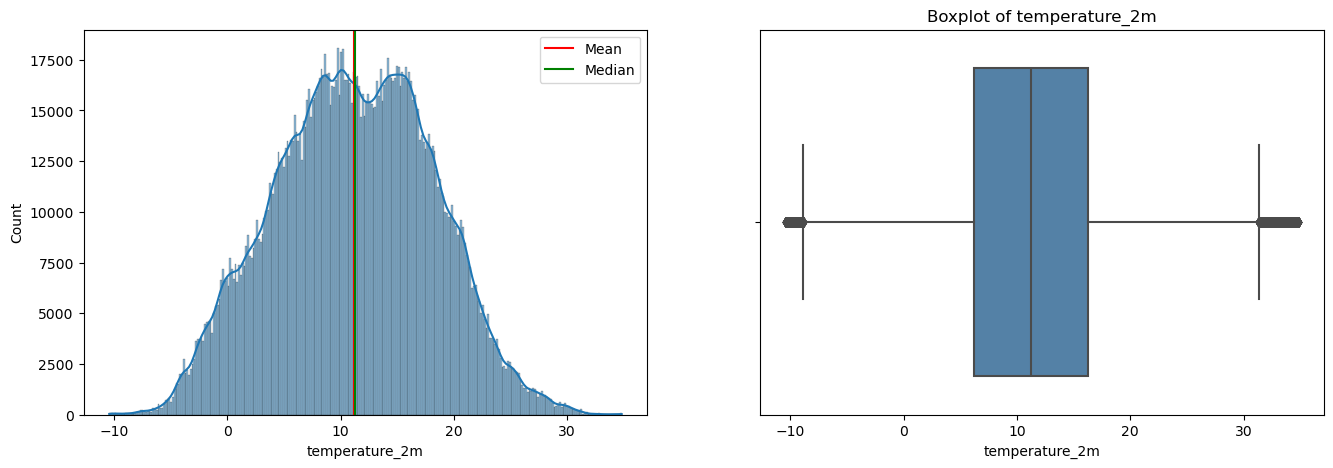

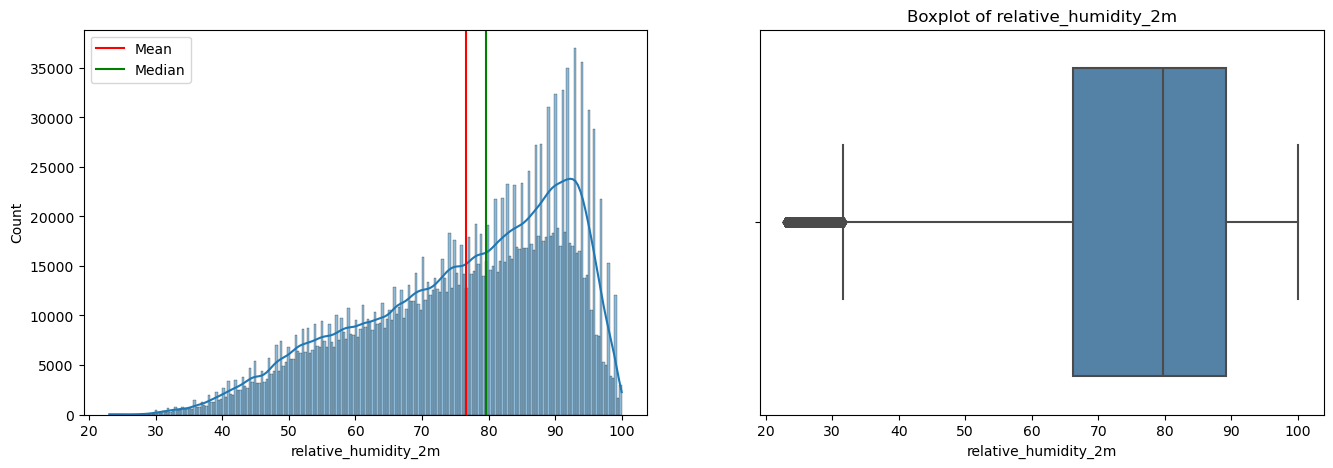

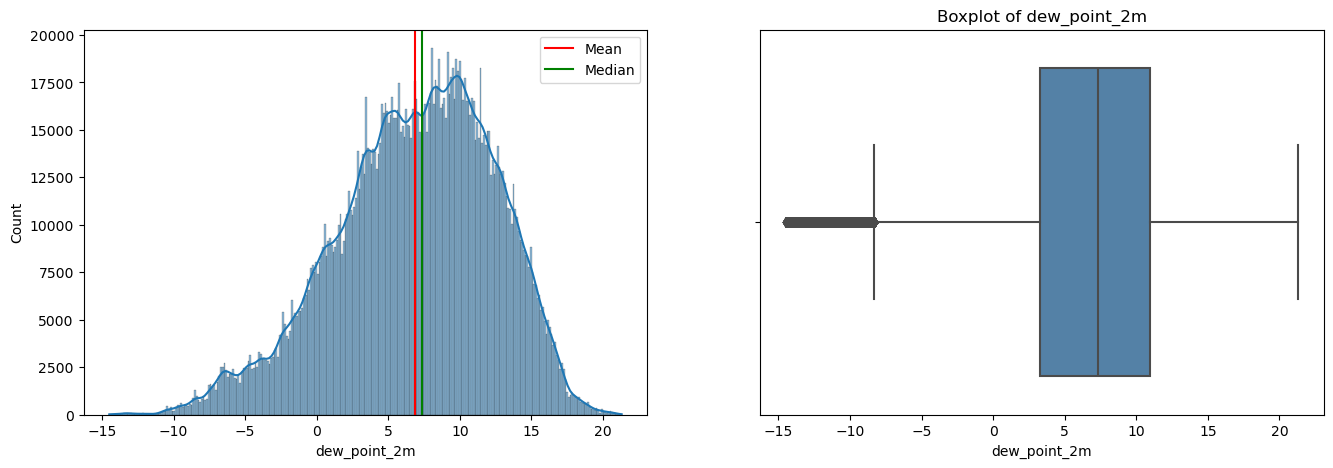

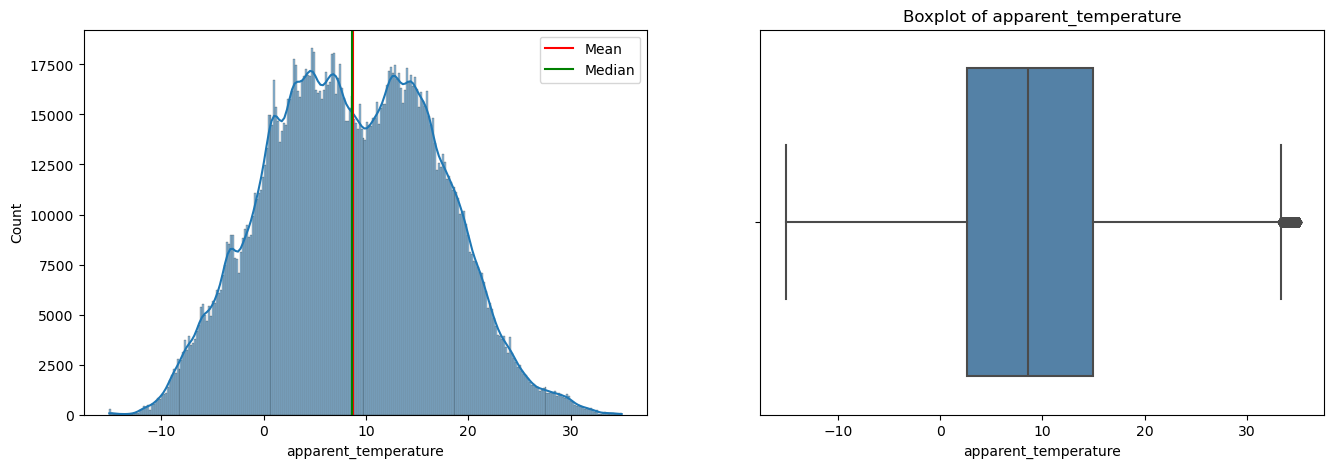

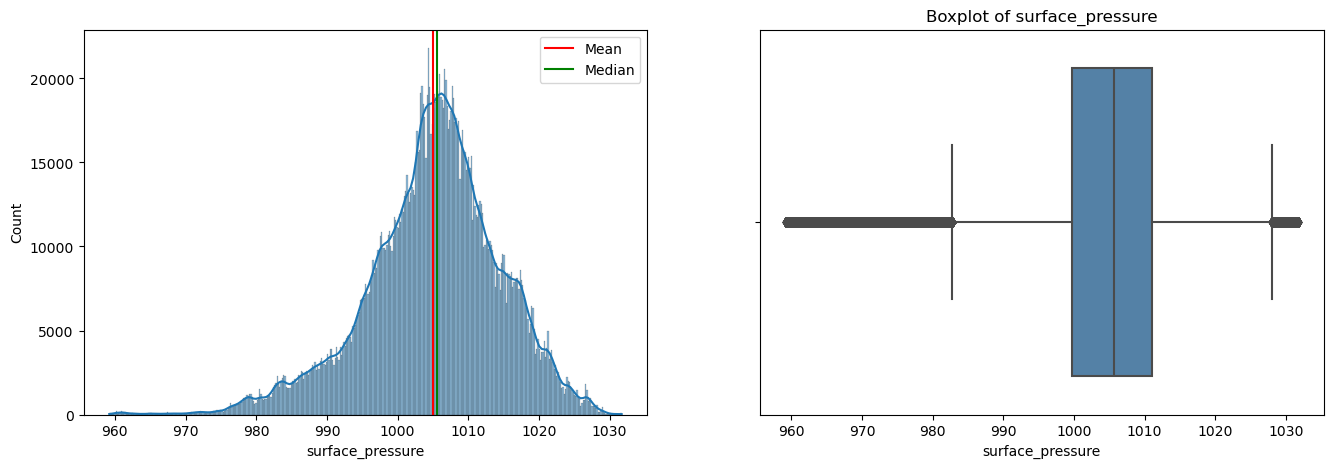

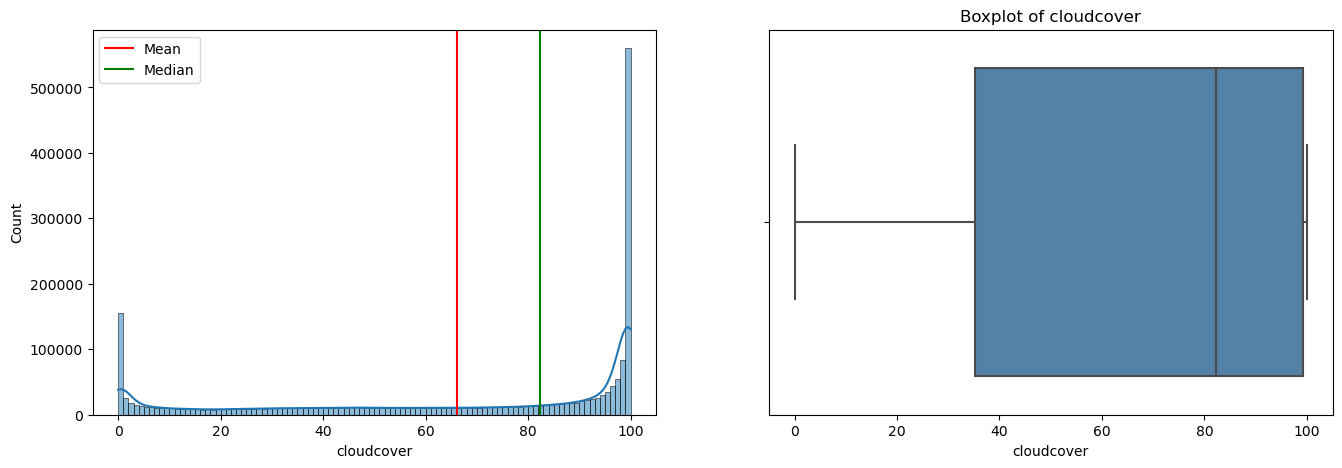

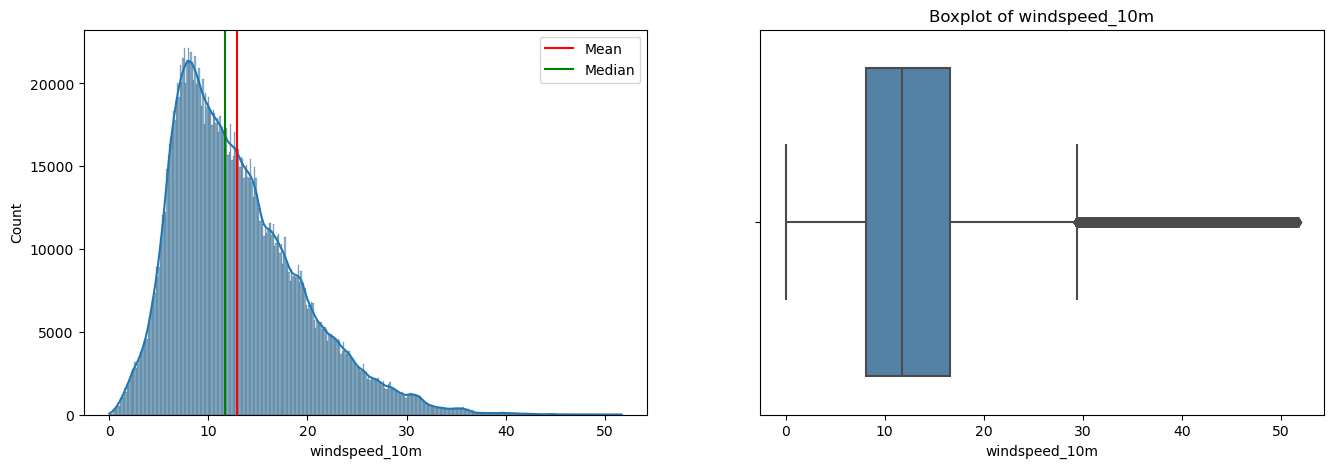

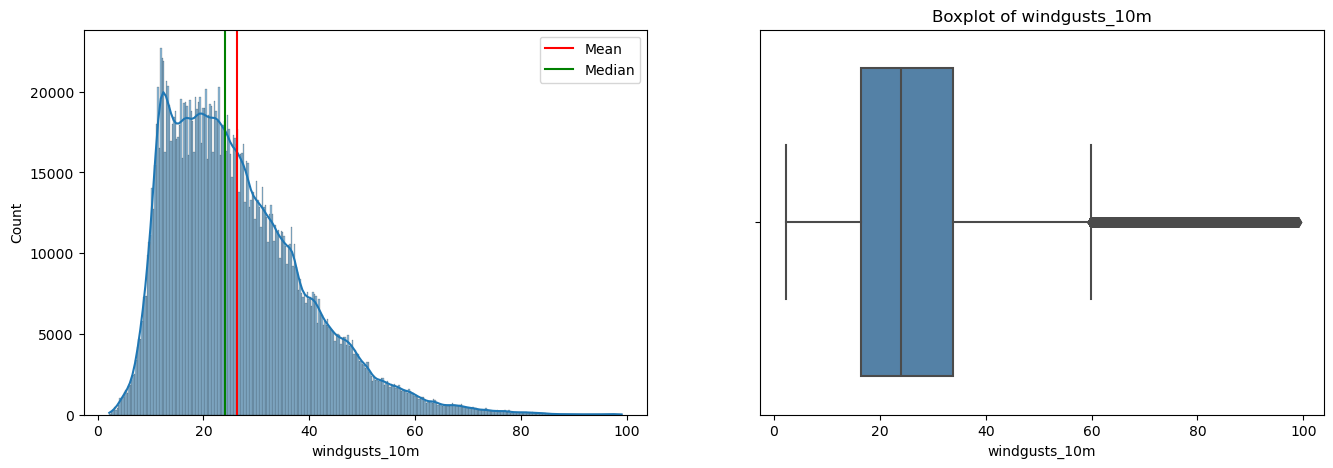

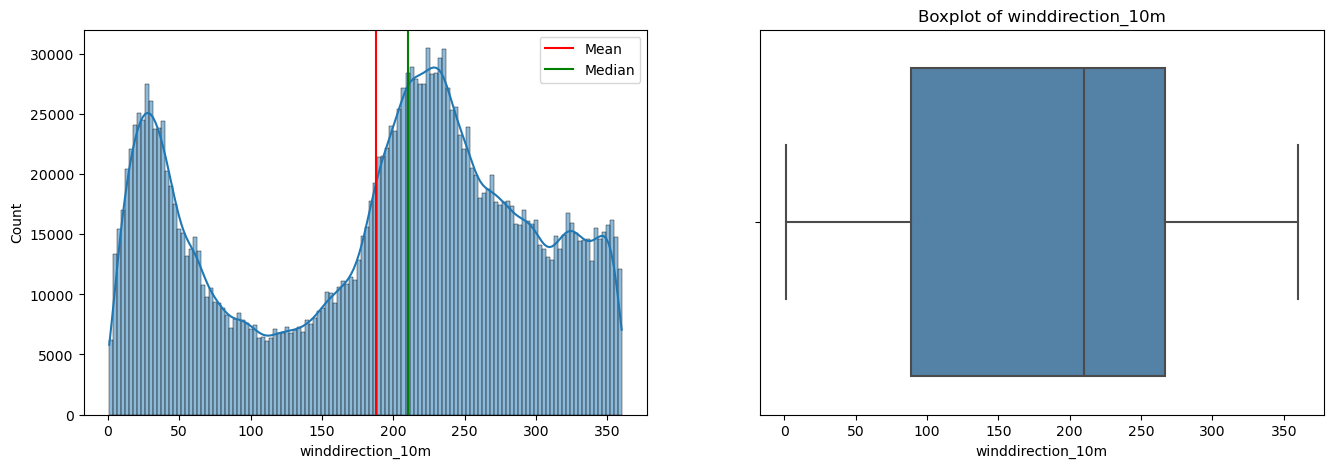

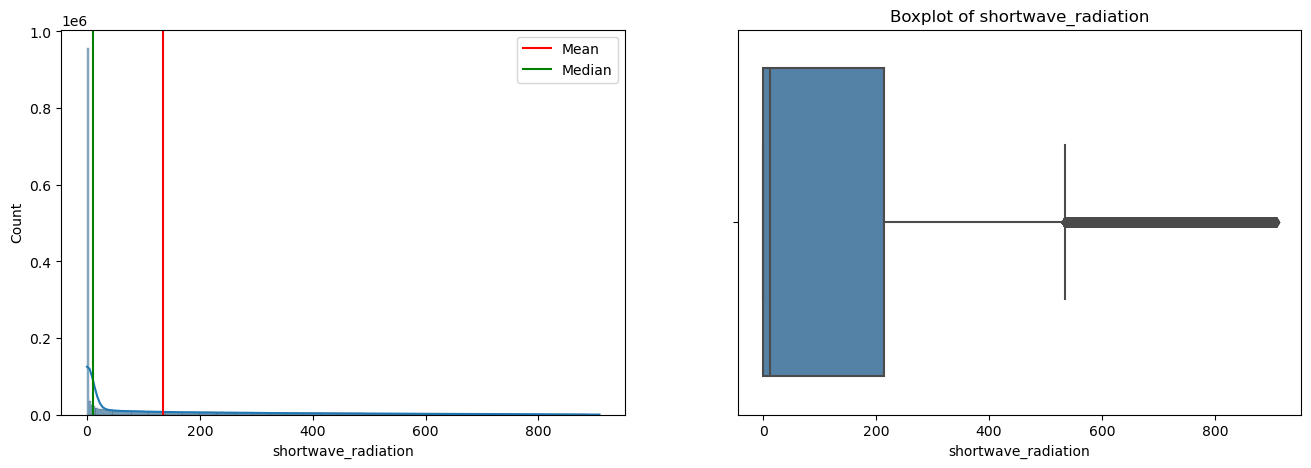

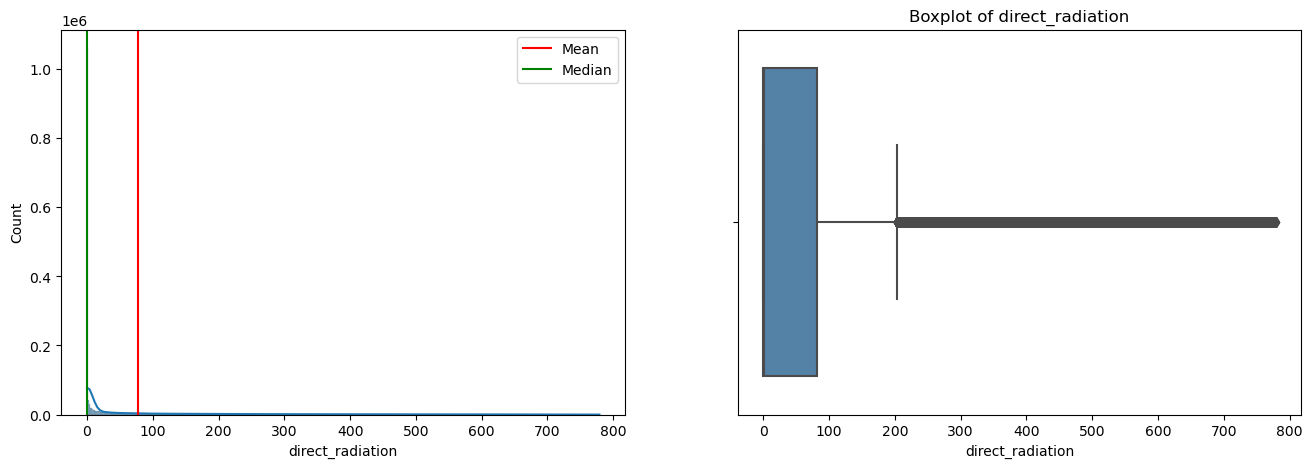

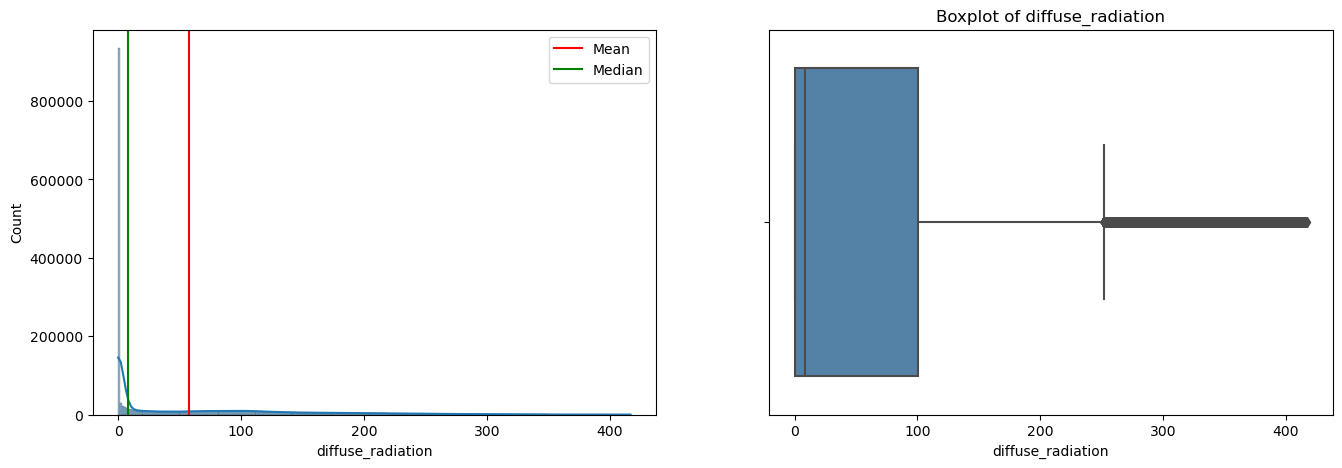

In [14]:
# Loop through column names in list
for col in list_features:
# Save column values, mean, and median to variables
    var = power_df_clean[col]
    var_mean = var.mean()
    var_median = var.median()
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
    # Plot a histogram of song tempo, with lines marking mean and median
    plt.subplot(1, 2, 1)
    sns.histplot(var, kde=True)
    plt.axvline(var_mean, c='r', label='Mean')
    plt.axvline(var_median, c='g', label='Median')
    plt.legend()
    # Plot the boxplot. We can use the seaborn boxplot code for this.
    plt.subplot(1, 2, 2)
    sns.boxplot(x=power_df_clean[col], color="steelblue")
    plt.title(f"Boxplot of {col}")
    
    plt.show()

## 📊 Feature Interpretation and Distribution Summary

| Feature Name             | Description                                                  | Typical Distribution       | Interpretation / Comments                                                                 |
|--------------------------|--------------------------------------------------------------|-----------------------------|-------------------------------------------------------------------------------------------|
| **Global_active_power**  | Total active power consumed (kW)                             | Right-skewed                | Most values 0.2–2.5 kW, peaks >5 kW indicate high usage. Spikes near 0 may be anomalies.  |
| **Global_reactive_power**| Reactive power (kW)                                          | Right-skewed, low values    | Mostly <0.5 kW, peaks during inductive load use. Useful for power quality analysis.       |
| **Voltage**              | Average voltage (V)                                          | Normal or slightly bimodal  | Centered around 235–245V. Fluctuations indicate grid stability or appliance startup.      |
| **Global_intensity**     | Current intensity (A)                                        | Similar to active power     | Correlates with Global_active_power. Peaks indicate high appliance use.                   |
| **Sub_metering_1**       | Kitchen appliances energy (Wh)                               | Zero-inflated               | Mostly 0, peaks during cooking times (e.g., lunch/dinner). Seasonal usage patterns.       |
| **Sub_metering_2**       | Laundry appliances energy (Wh)                               | Zero-inflated, sparse       | Peaks once or twice a day. Strong weekly trends (e.g., weekend laundry).                  |
| **Sub_metering_3**       | Water heater & AC energy (Wh)                                | Less sparse, low skew       | More frequent use, indicates baseline consumption. Seasonal patterns may appear.          |
| **Weather Features**    | Connected through API          | Variable                     | The distrubitions are vary variable, might need to consider to drop some features if necessary to help in our modelling                |


Lets plot all our taret variable which is the Global Active Power against all other features in our data set

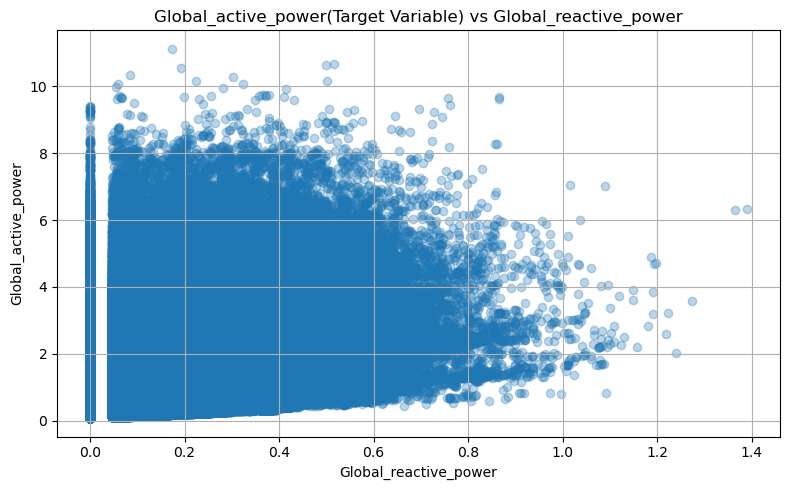

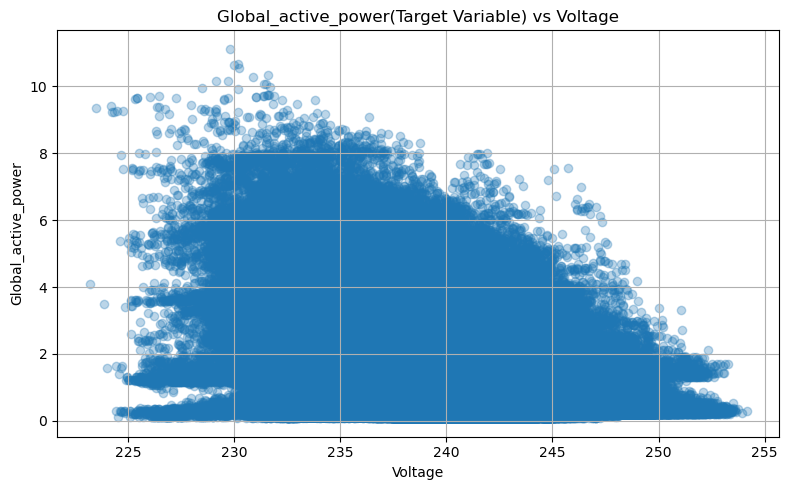

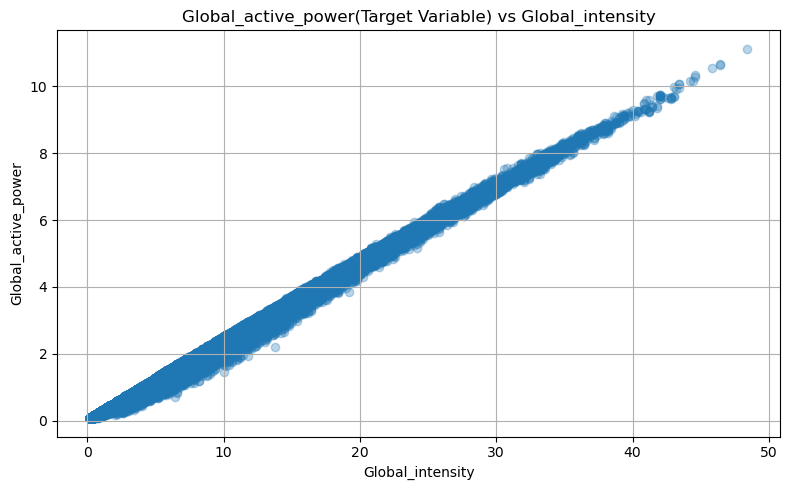

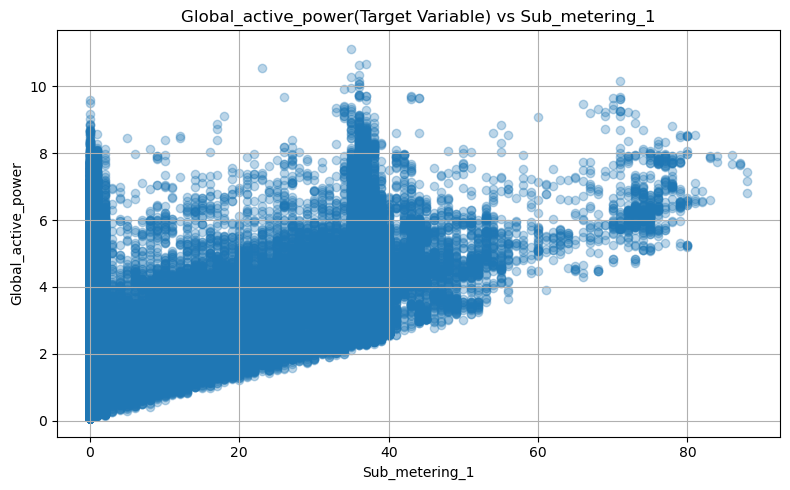

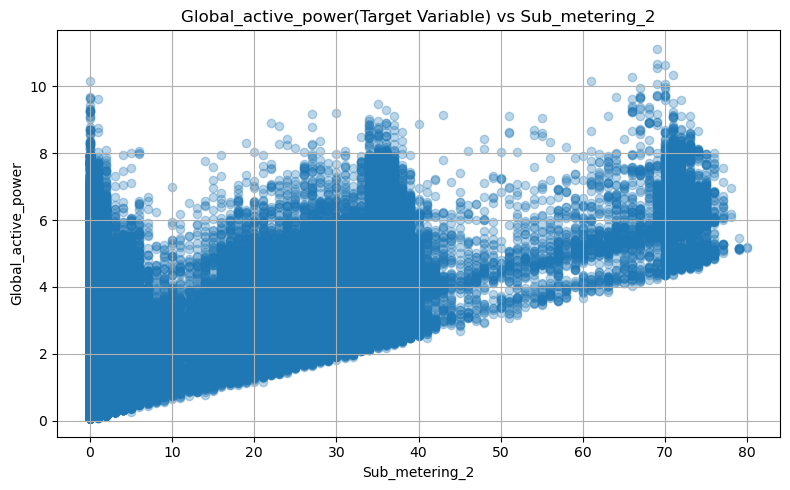

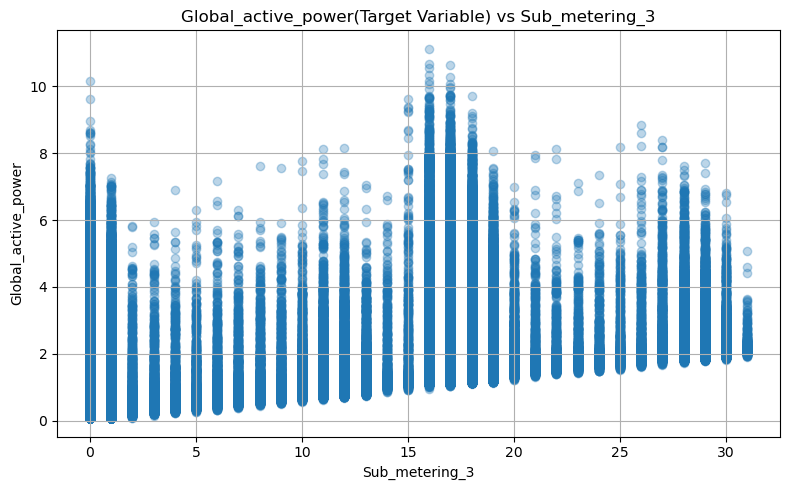

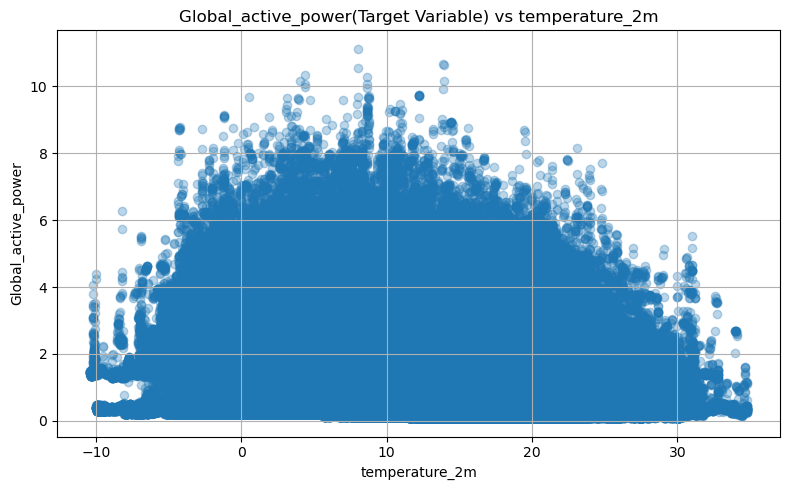

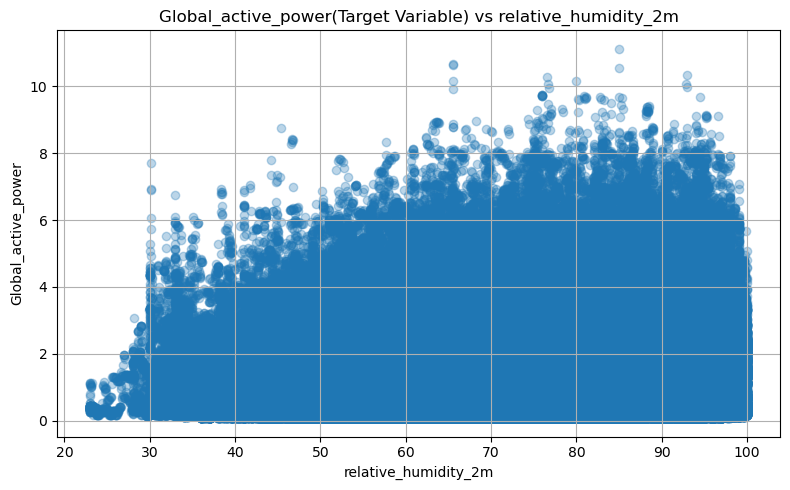

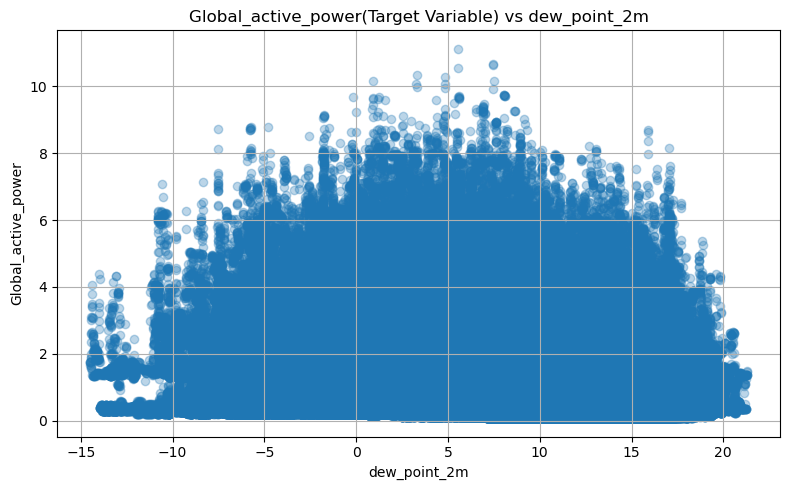

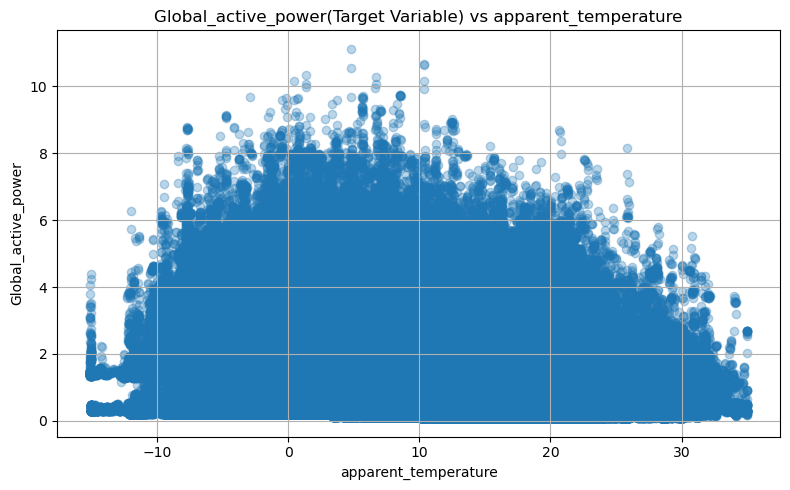

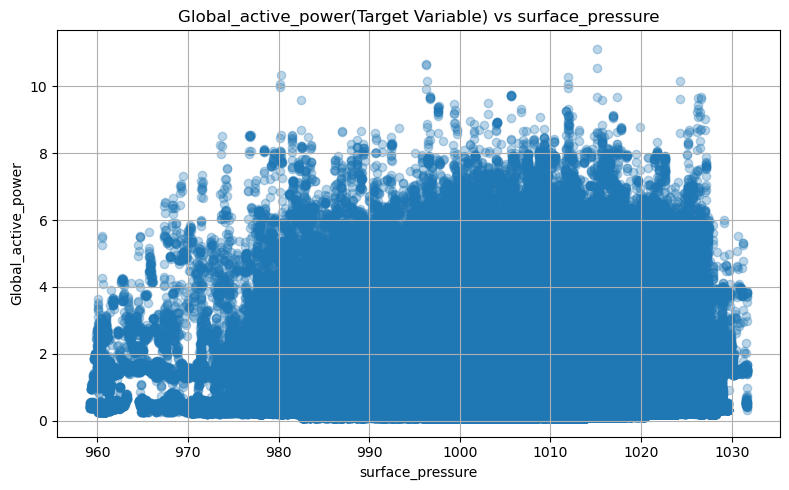

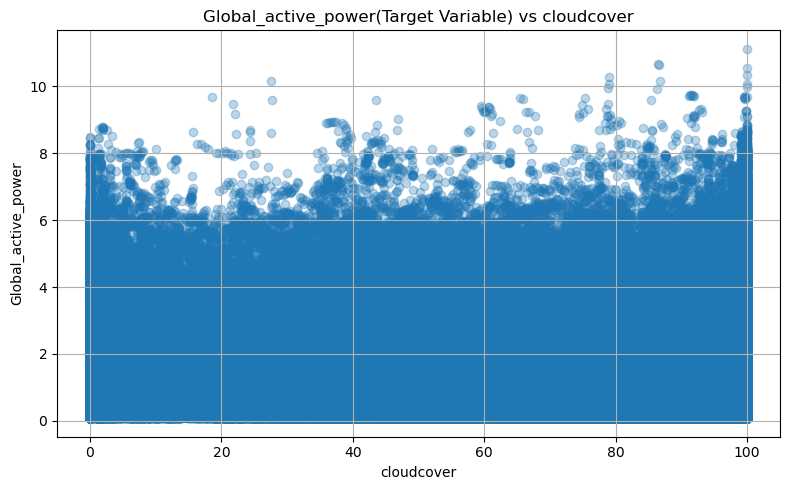

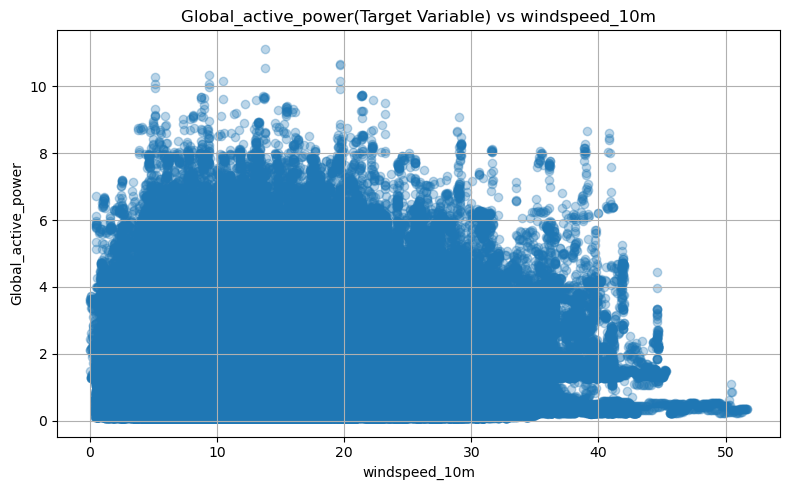

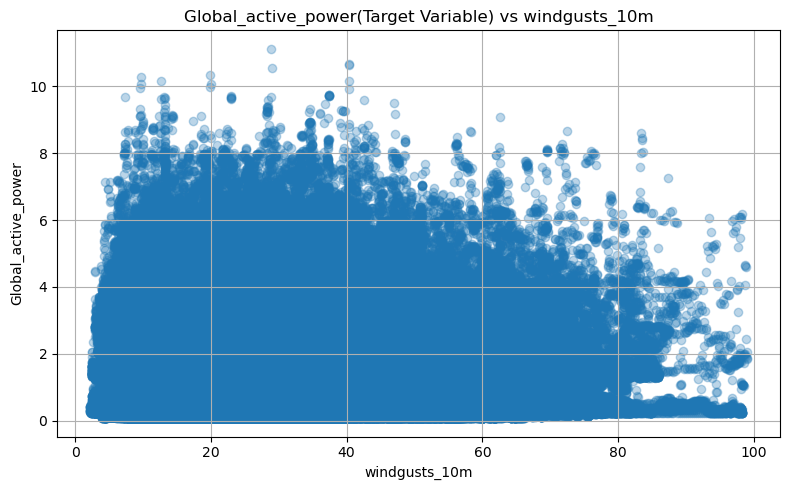

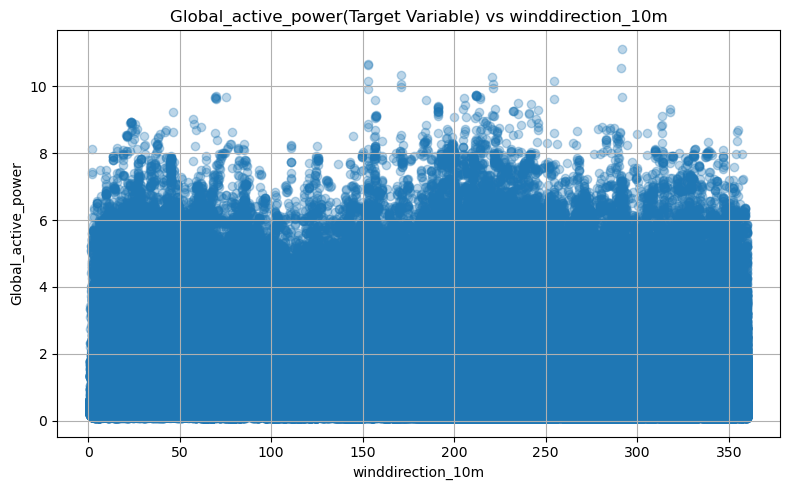

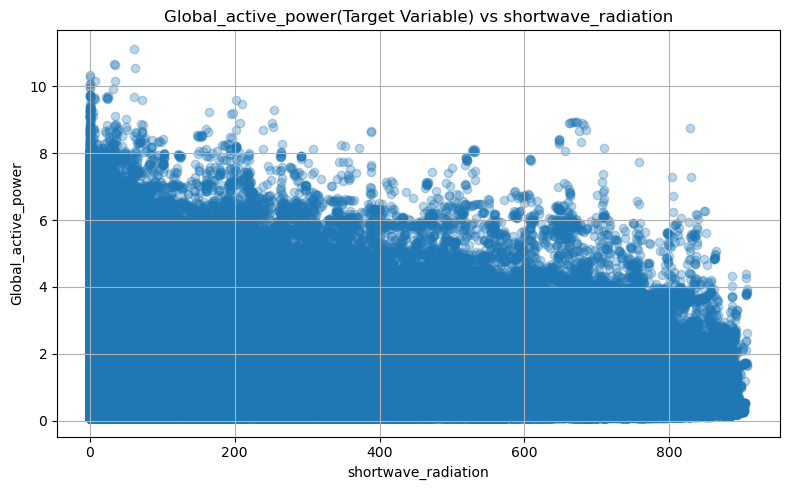

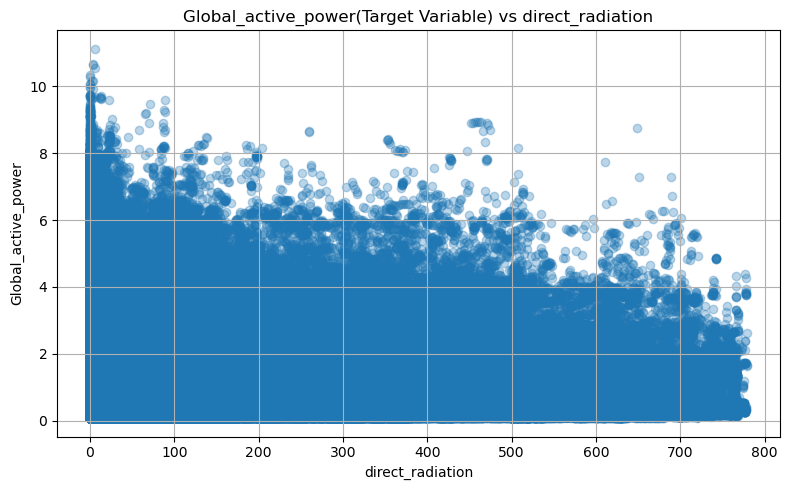

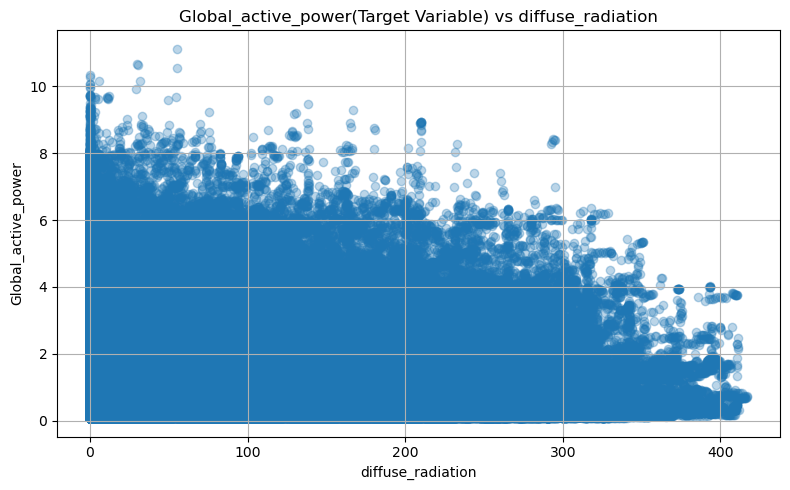

In [ ]:
# Scatter plots of all variables vs Global_active_power
for col in power_df_clean.columns:
    if col != 'Global_active_power':
        plt.figure(figsize=(8, 5))
        plt.scatter(power_df_clean[col], power_df_clean['Global_active_power'], alpha=0.3)
        plt.xlabel(col)
        plt.ylabel('Global_active_power')
        plt.title(f'Global_active_power vs {col}')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Based on the graphs above, we can see that there are some variables that have a strong correlation with `Global_active_power`, such as **Intensity**. The scatter plot show that `Global_active_power` has a positive correlation with **Intensity**,

Other variables like **Sub_metering_1,Sub_metering_2, and Sub_metering_3** also show some correlation but are not as strong.

The weather API fearures doesnt seem to show much influence on our target variable Global_active_power

 Next we can visulalize and intrepret this much better with a correlation matrix 



## Correlation Matrix


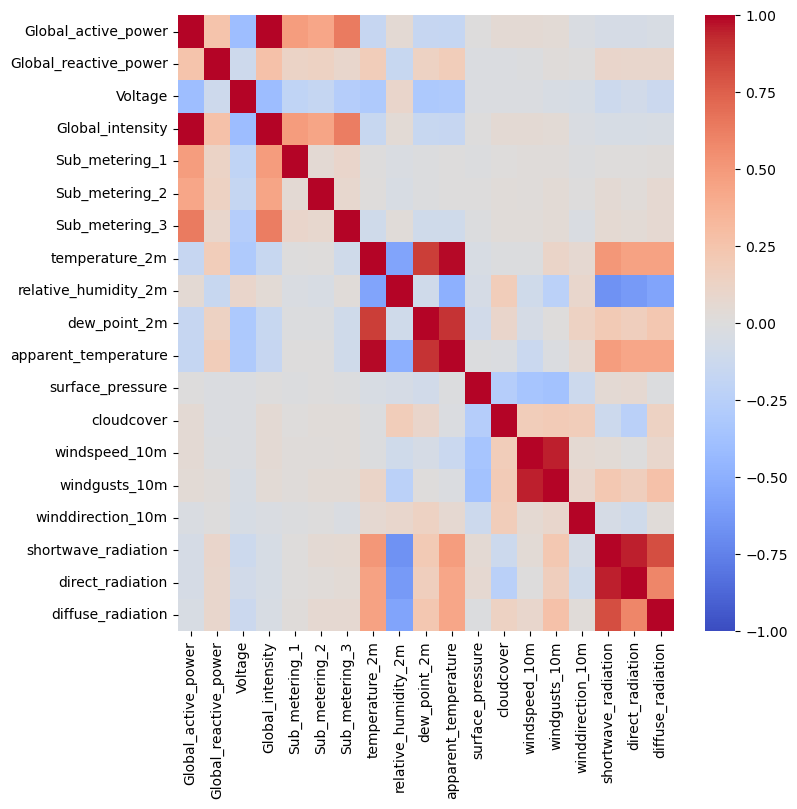

In [15]:
plt.figure(figsize=(8,8))
sns.heatmap(
    power_df_clean.corr(numeric_only=True).round(2),
    annot=False,
    fmt='g',
    center=0,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot_kws={'size': 10}
)
plt.show()

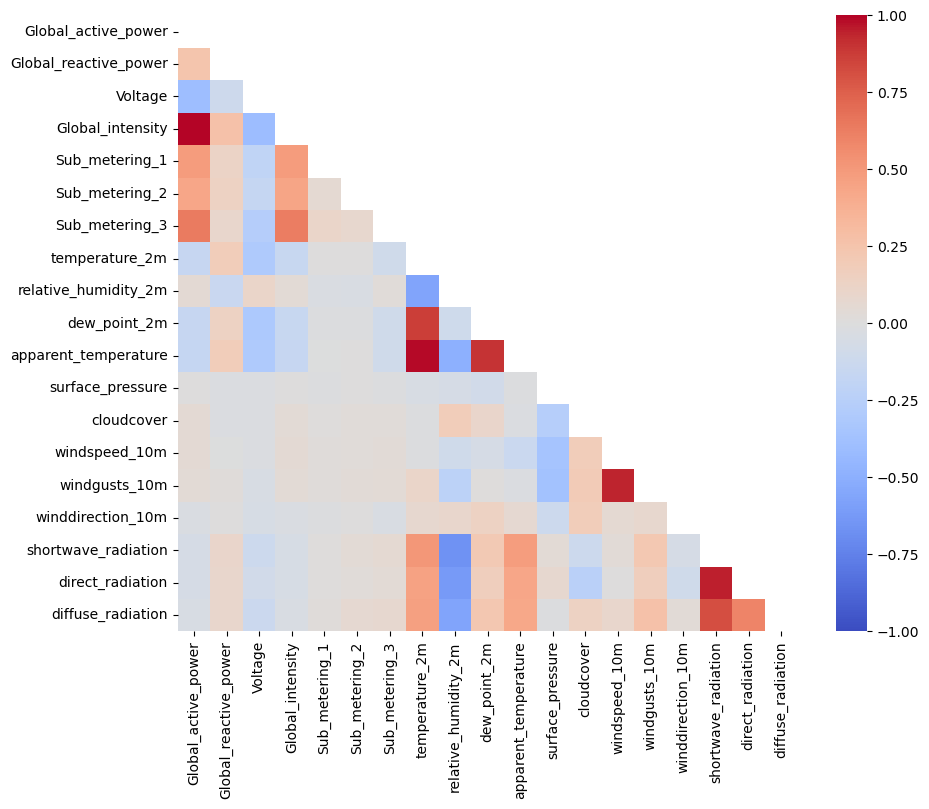

In [17]:
#We can try to visualize the correlation matrix with a mask to only show the lower triangle, which can make it easier to read.
mask = np.triu(np.ones_like(power_df_clean.corr(), dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    power_df_clean.corr(numeric_only=True),
    annot=True,
    mask=mask,
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    cmap='coolwarm',  # Use coolwarm color map
    annot_kws={'size': 10}
)
plt.show()

In [18]:
# Lets look at the correlation of each feature with Global_active_power
power_df_clean.corr(numeric_only=True)['Global_active_power'].sort_values(ascending=False)

Global_active_power      1.000000
Global_intensity         0.998889
Sub_metering_3           0.638555
Sub_metering_1           0.484401
Sub_metering_2           0.434569
Global_reactive_power    0.247017
windspeed_10m            0.051084
relative_humidity_2m     0.049883
cloudcover               0.047185
windgusts_10m            0.044151
surface_pressure         0.002360
winddirection_10m       -0.030976
diffuse_radiation       -0.041187
direct_radiation        -0.056569
shortwave_radiation     -0.056681
temperature_2m          -0.160820
dew_point_2m            -0.161119
apparent_temperature    -0.169106
Voltage                 -0.399762
Name: Global_active_power, dtype: float64

 There are some features that have a strong positive correlation with Global_active_power, such as Global_intensity, Sub_metering_3, Sub_metering_1, Sub_metering_2 and Global_reactive_power and negative correlation with Voltage, also from the weather API, it seems the features like dew_point_2m , temperature_2m and apparent_temperature are sort of the main features having some correlations with Global_active_power.These features may be useful for predicting Global_active_power in a machine learning model.

Lets take a look at the correlation matrix to see how the features are correlated with each other instead of the target vaiable  Global_active_power

In [19]:
X=power_df_clean.drop(columns='Global_active_power')
X.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,cloudcover,windspeed_10m,windgusts_10m,winddirection_10m,shortwave_radiation,direct_radiation,diffuse_radiation
Datetime,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,0.418,234.84,18.4,0.0,1.0,17.0,7.120,94.200,6.240,4.100,1012.400,100.0,14.280,31.100,329.400,8.000,0.0,8.000
2006-12-16 17:25:00,0.436,233.63,23.0,0.0,1.0,16.0,7.108,94.167,6.225,4.092,1012.417,100.0,14.242,31.075,329.417,7.833,0.0,7.833
2006-12-16 17:26:00,0.498,233.29,23.0,0.0,2.0,17.0,7.097,94.133,6.210,4.083,1012.433,100.0,14.203,31.050,329.433,7.667,0.0,7.667
2006-12-16 17:27:00,0.502,233.74,23.0,0.0,1.0,17.0,7.085,94.100,6.195,4.075,1012.450,100.0,14.165,31.025,329.450,7.500,0.0,7.500
2006-12-16 17:28:00,0.528,235.68,15.8,0.0,1.0,17.0,7.073,94.067,6.180,4.067,1012.467,100.0,14.127,31.000,329.467,7.333,0.0,7.333


In [20]:
corr_df = X.corr()

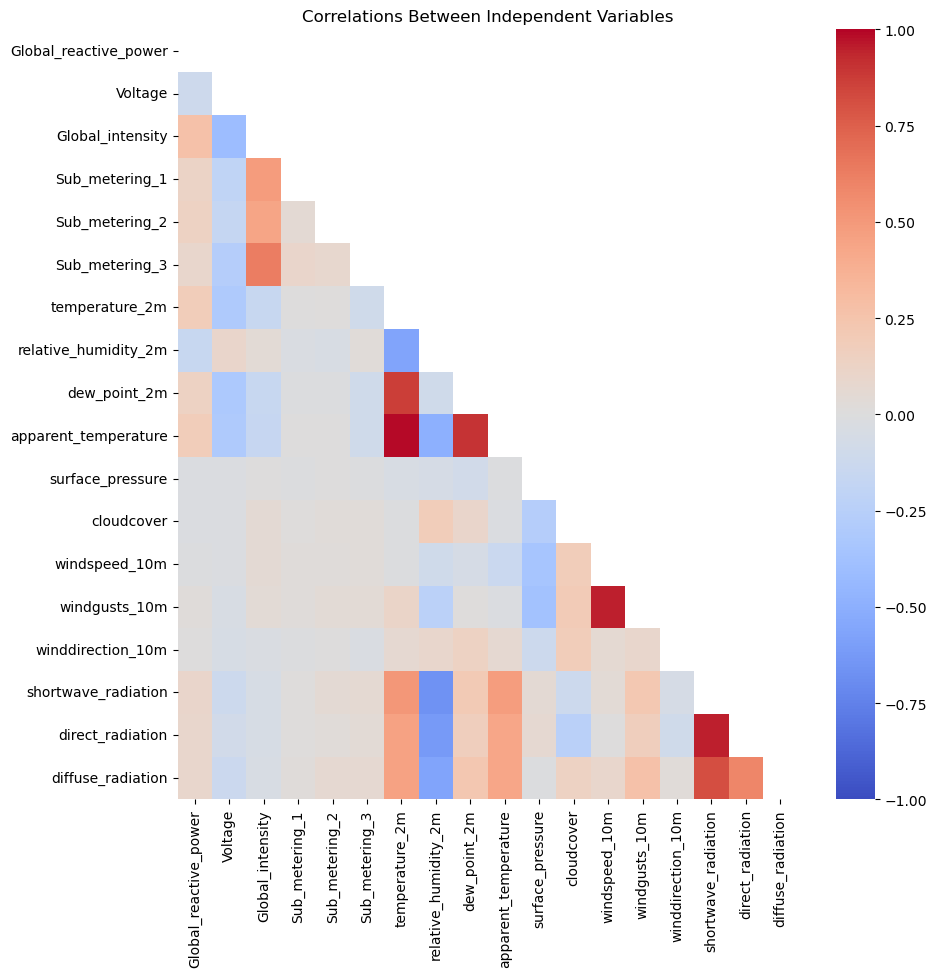

In [21]:
# Calculate all the correlations between each independent variable
corr_df = X.corr()

# Mask for upper-triangular
mask = np.triu(corr_df)

# Visualize with seaborn
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_df.round(2), 
    annot=True, 
    vmax=1, 
    vmin=-1, 
    center=0, 
    cmap="coolwarm", 
    mask=mask
)

plt.title("Correlations Between Independent Variables")
plt.show()


From the Correlation matrix for independednt variables we can, find the following interpretations


| **Correlation Type** | **Variables Involved** | **Relationship Explanation** |
|----------------------|----------------------|-----------------------------|
| 🔴 **Strong Positive** | **Global Intensity ↔ Global Reactive Power** | More electrical intensity leads to higher power consumption. |
| 🔴 **Strong Positive** | **Temperature ↔ Apparent Temperature** | Apparent temperature closely follows actual temperature, adjusted for humidity/wind. |
| 🔴 **Strong Positive** | **Shortwave Radiation ↔ Direct Radiation** | More incoming solar radiation increases direct radiation, affecting solar energy production. |
| 🔵 **Strong Negative** | **Voltage ↔ Global Reactive Power** | As voltage drops, power consumption often increases, a typical behavior in energy management. |
| 🔵 **Strong Negative** | **Relative Humidity ↔ Temperature** | Higher temperatures reduce relative humidity, as warm air holds more moisture. |
| 🔵 **Strong Negative** | **Wind Gusts ↔ Wind Speed** | Gusts represent temporary bursts, sometimes negatively correlated with steady wind speeds. |

It would make sense to drop some of these highly positve and negative correlations features from our dataset to avoid multicollinearity issues in our model, in the preprocessing notebook in future.

## Patterns in Observations Over Time

The data is a multivariate time series and the best way to understand a time series is to create line plots.

We can start off by creating a separate line plot for each of the variables.

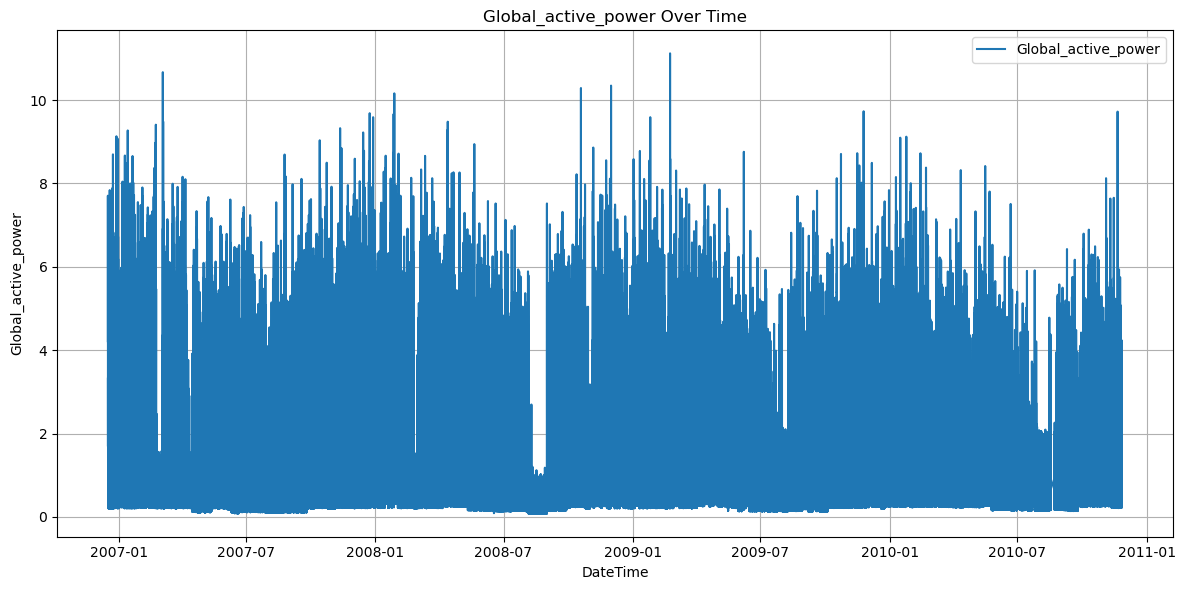

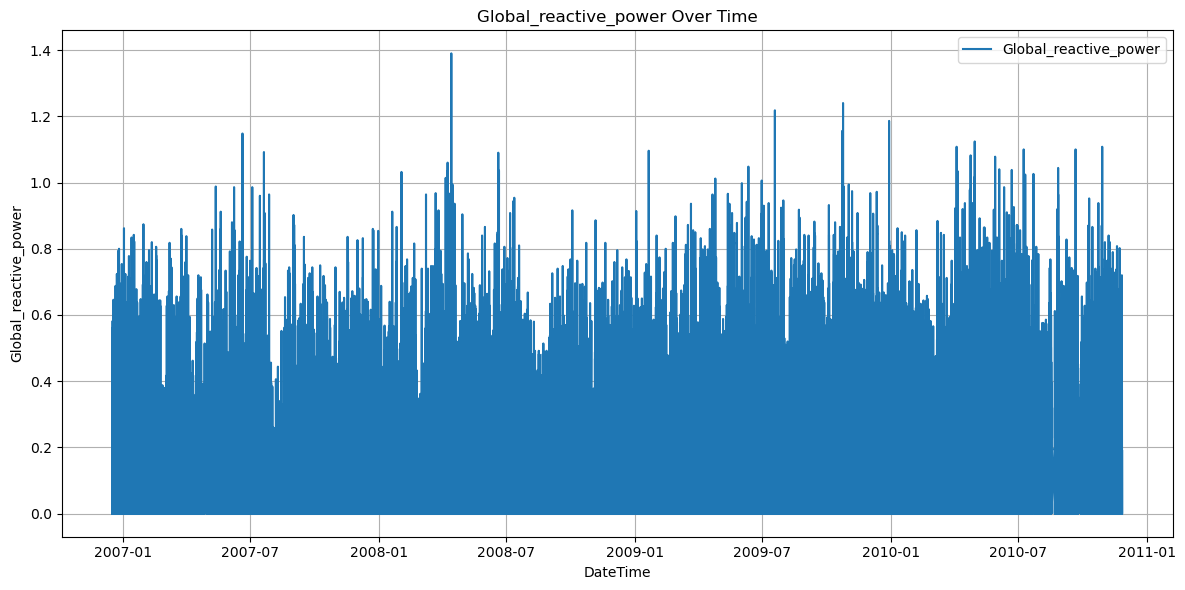

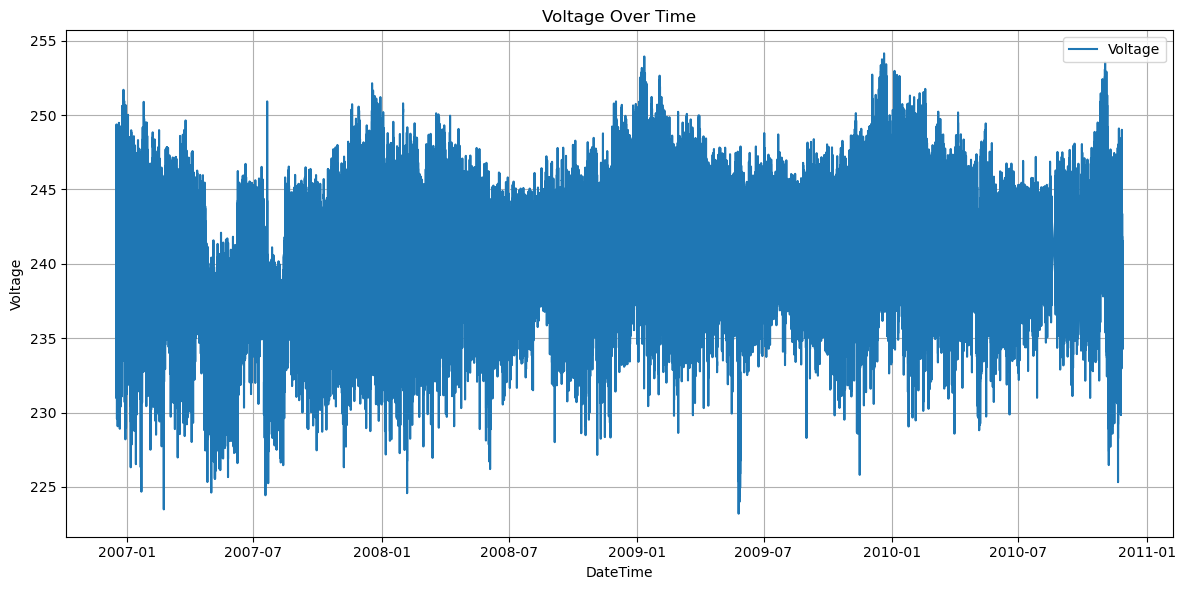

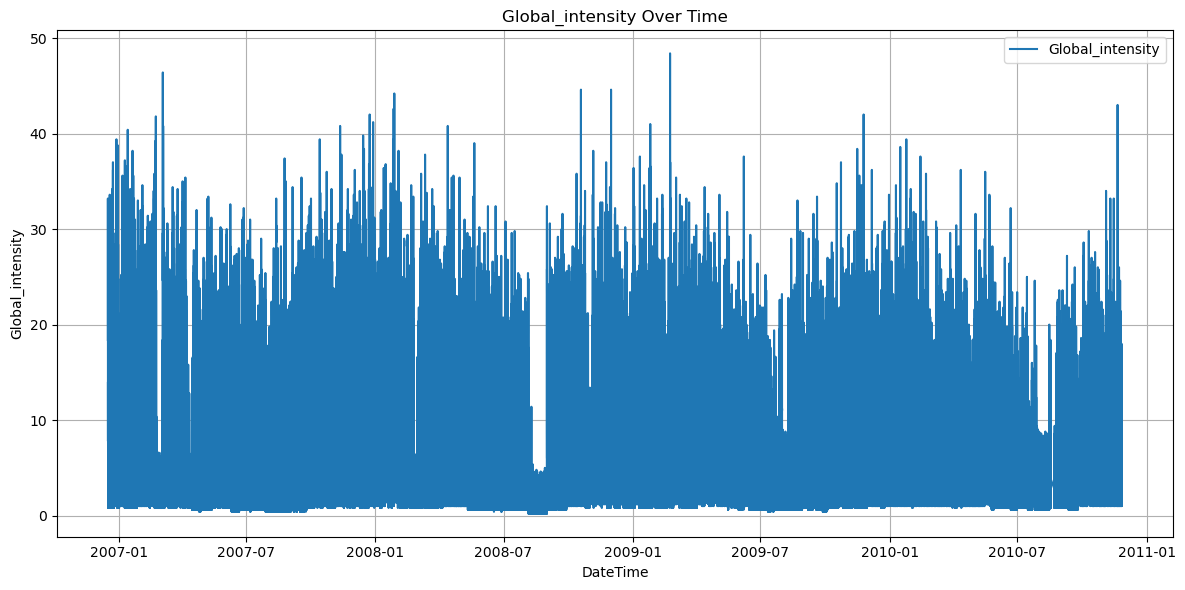

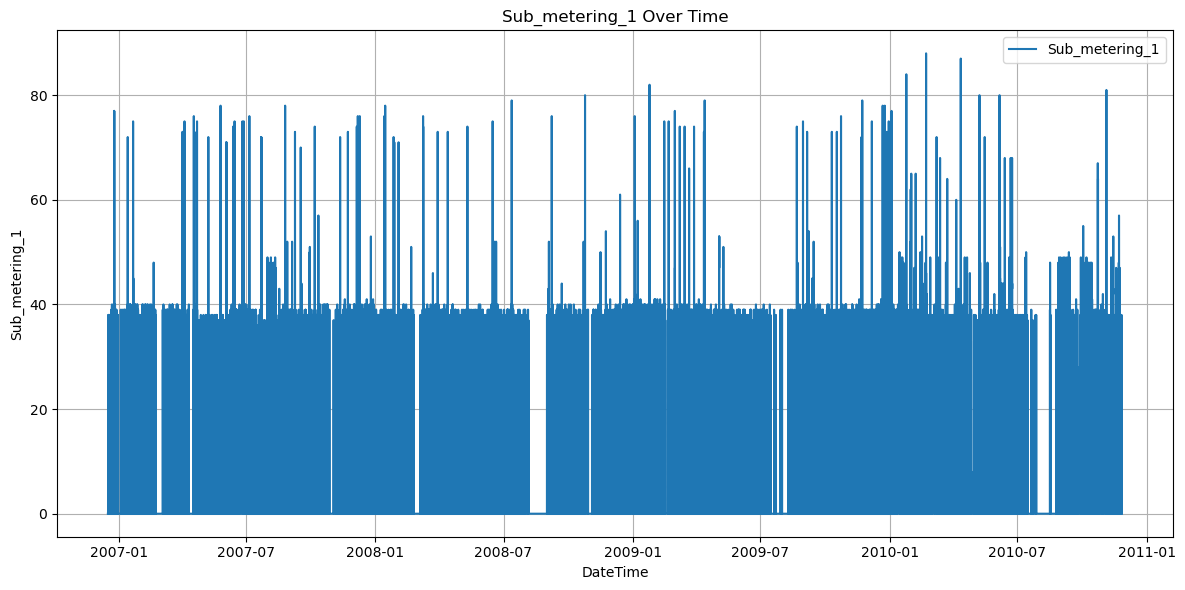

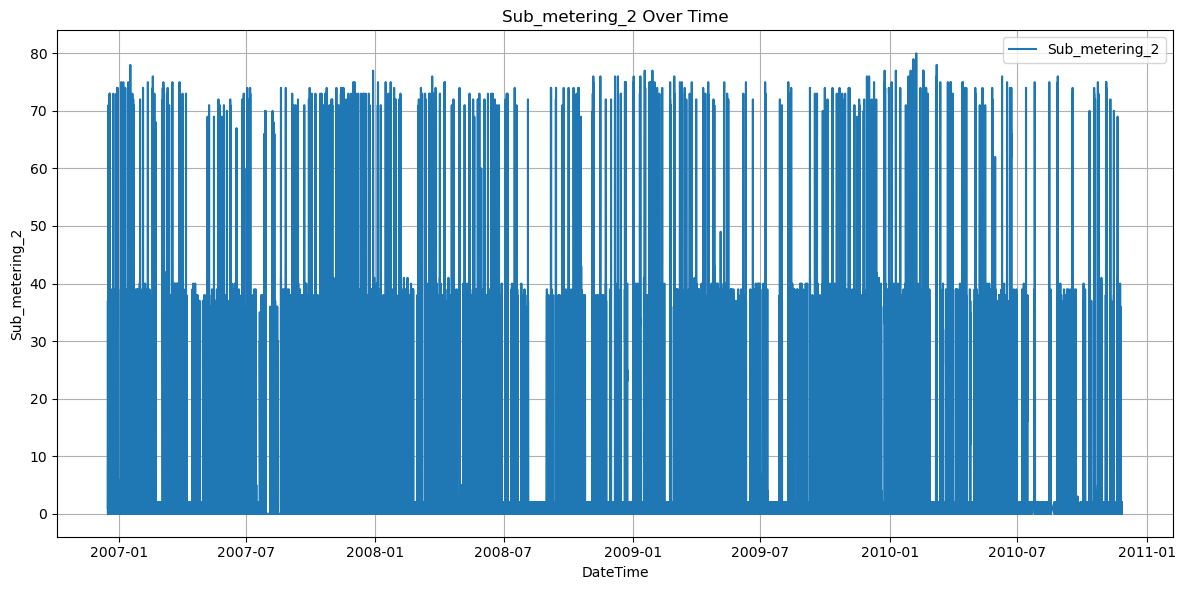

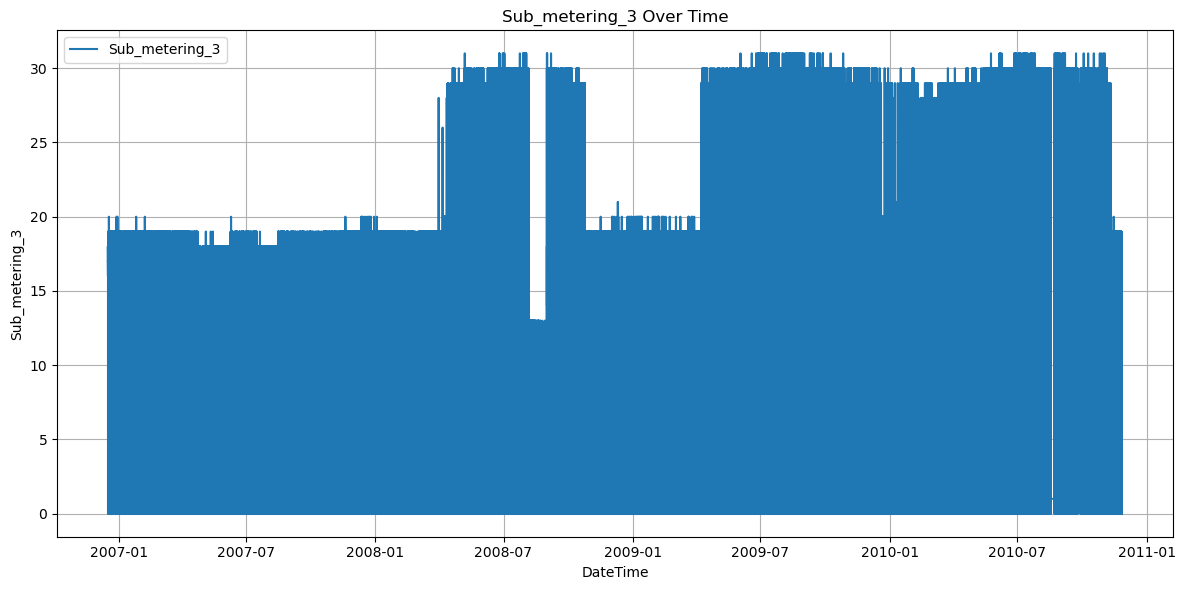

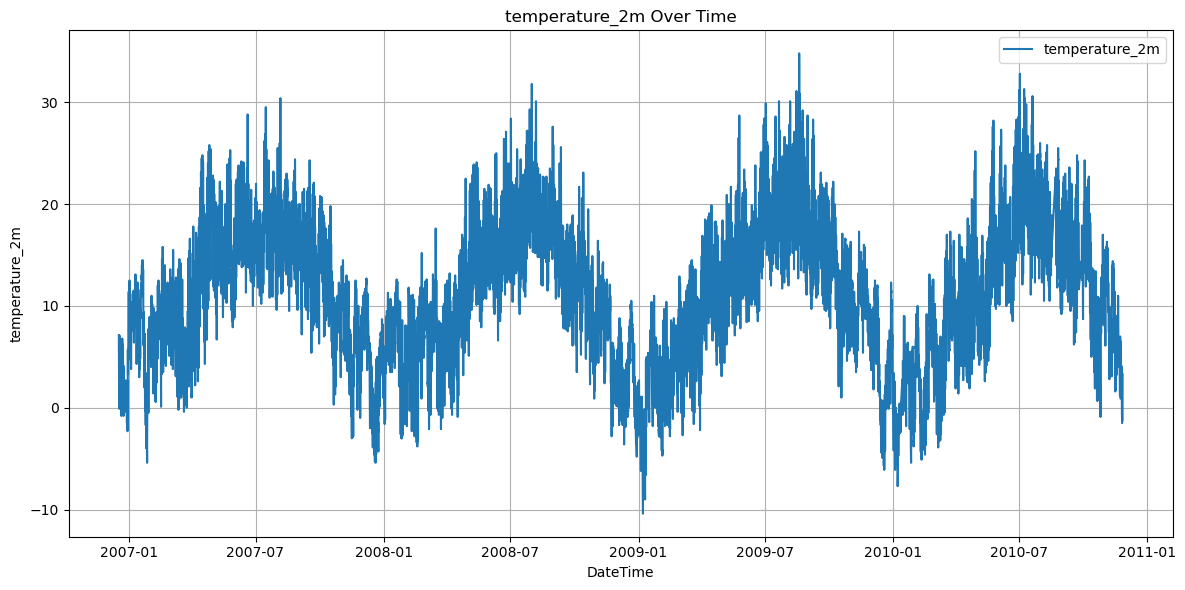

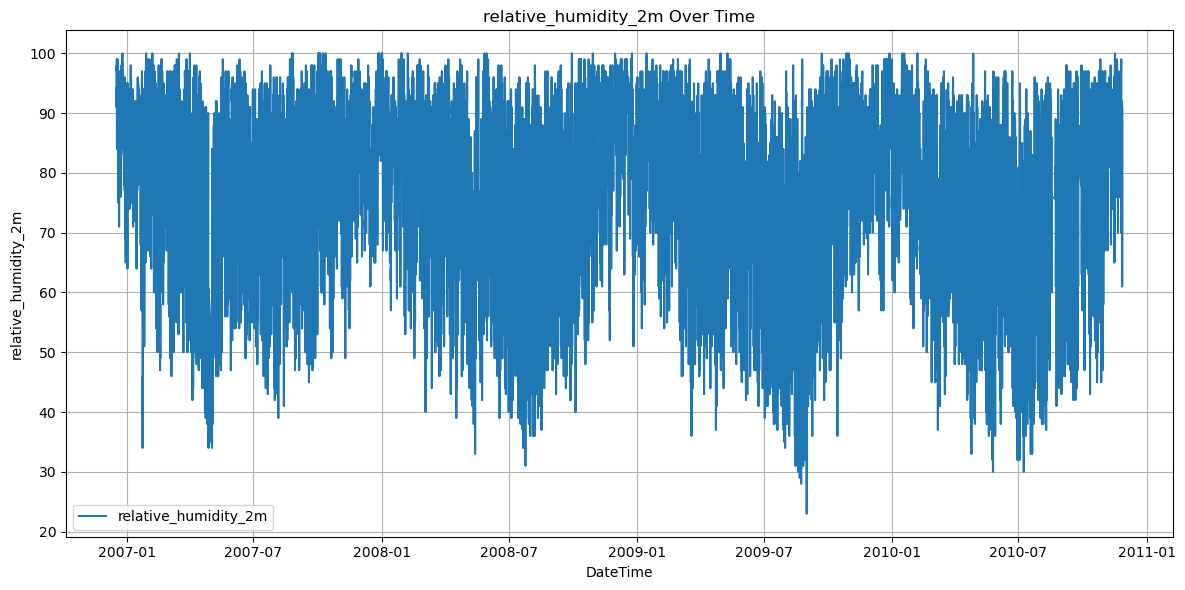

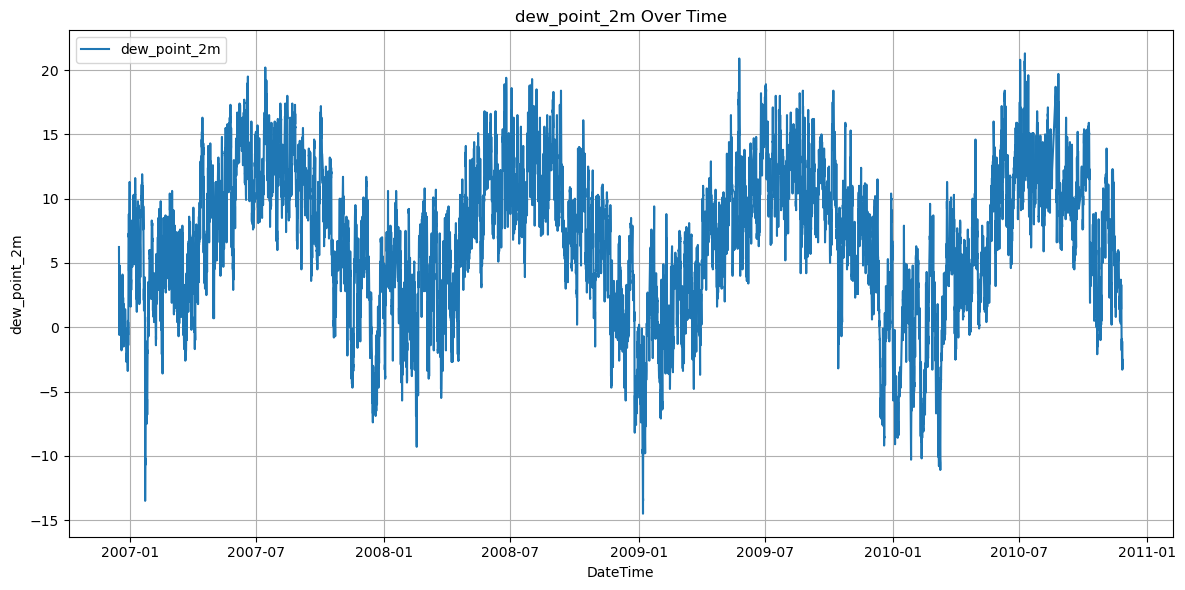

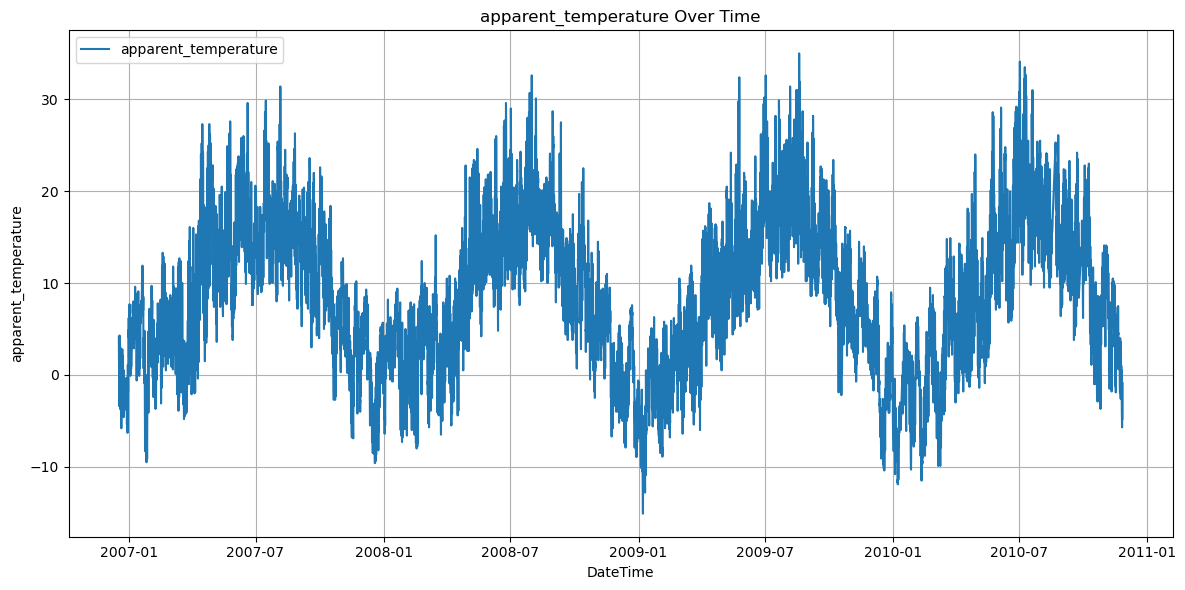

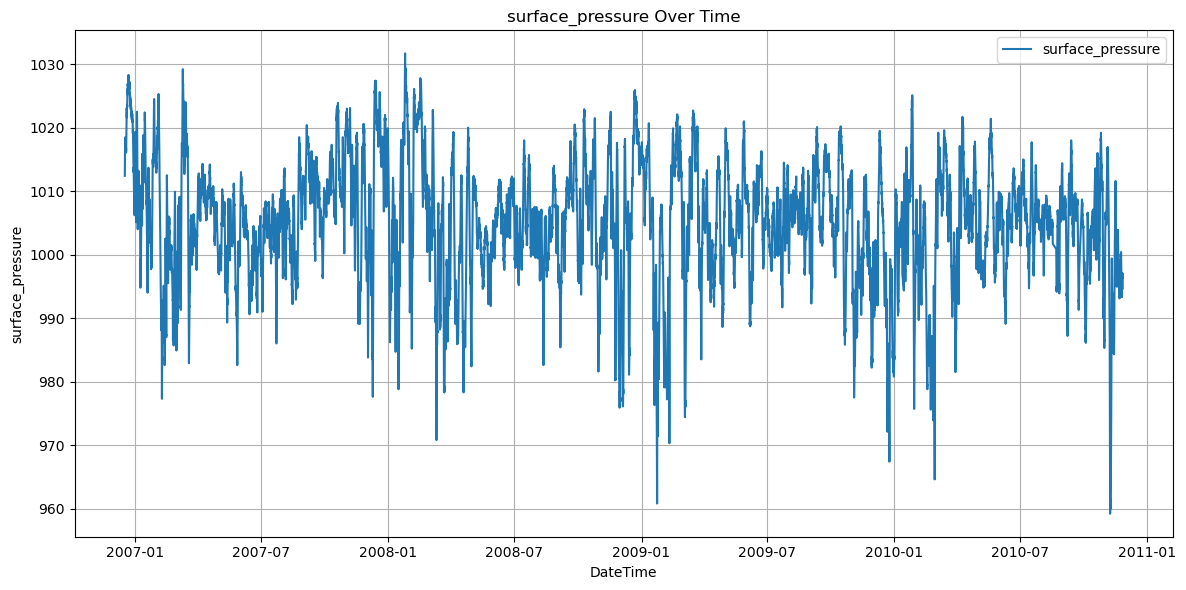

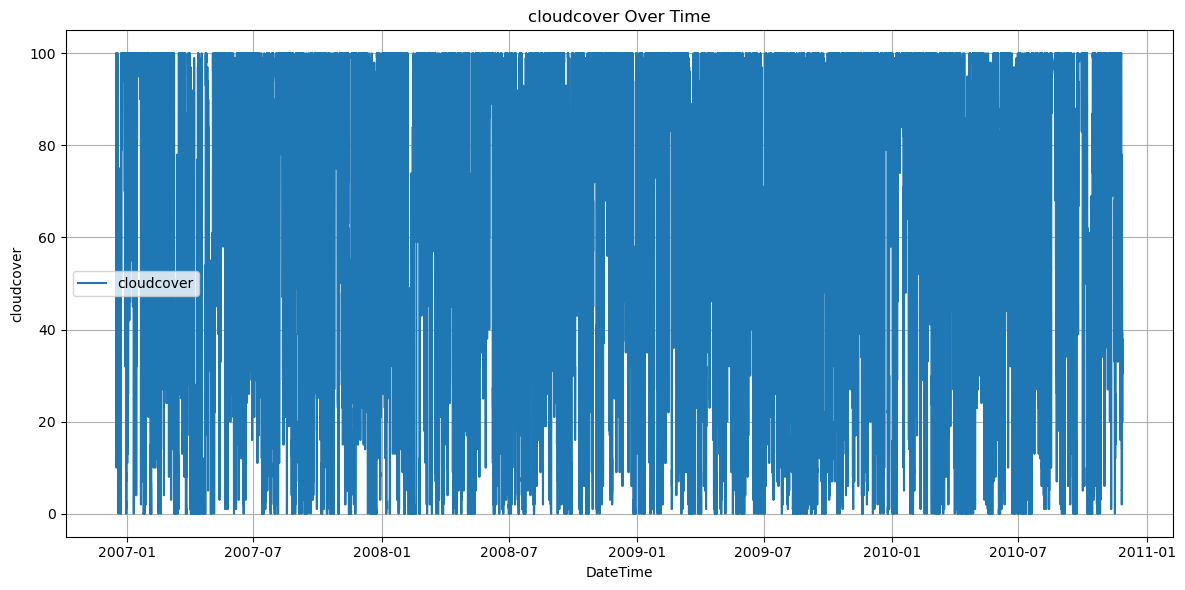

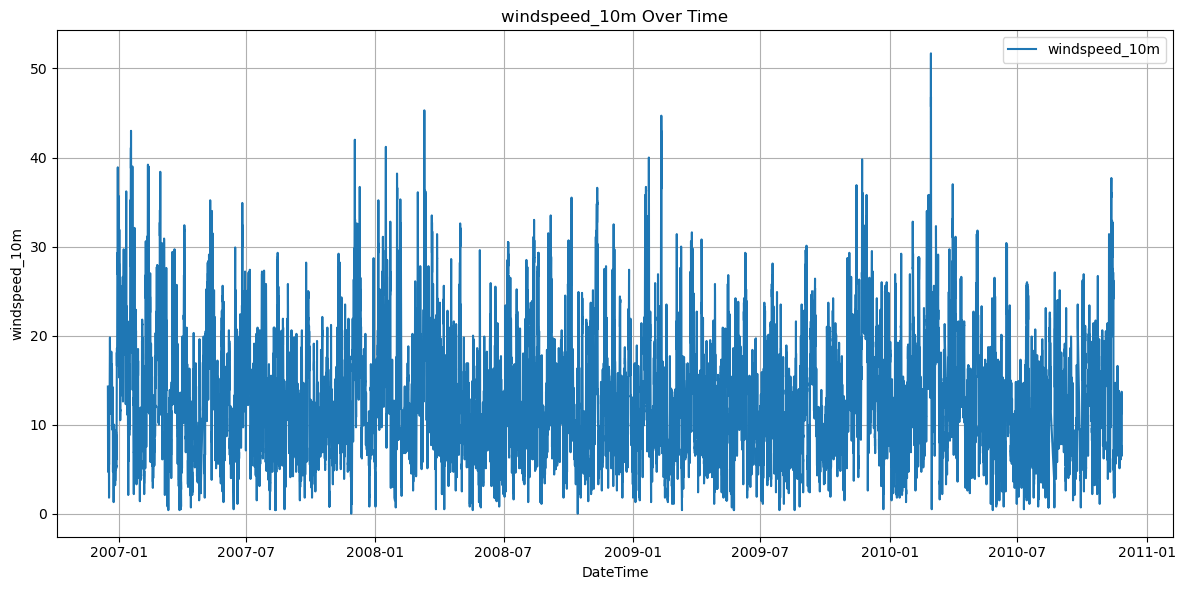

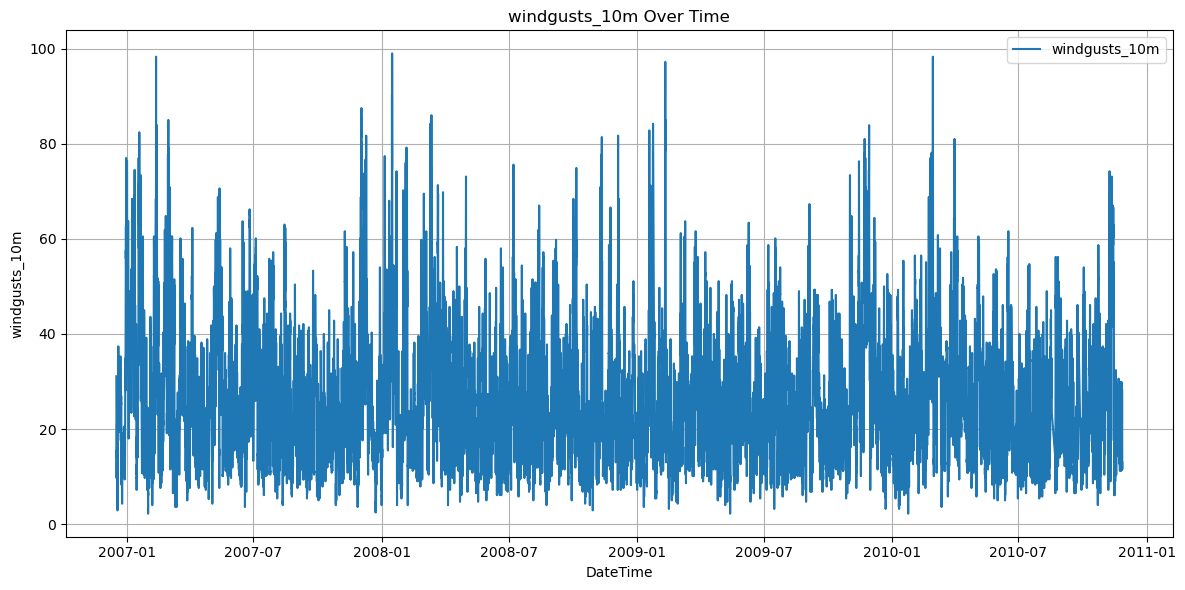

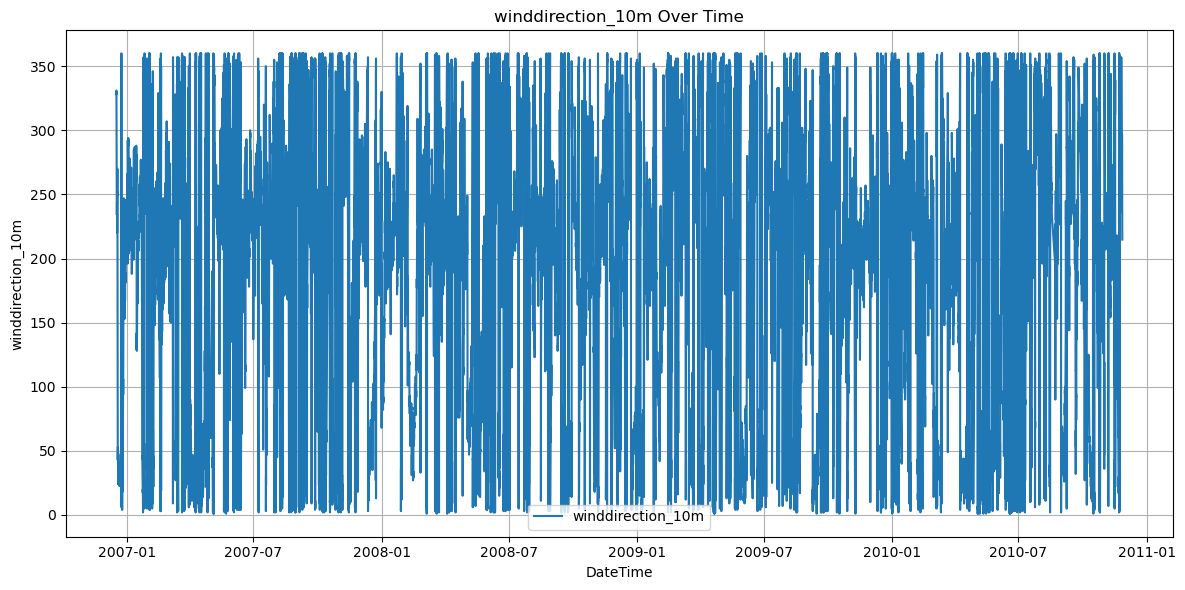

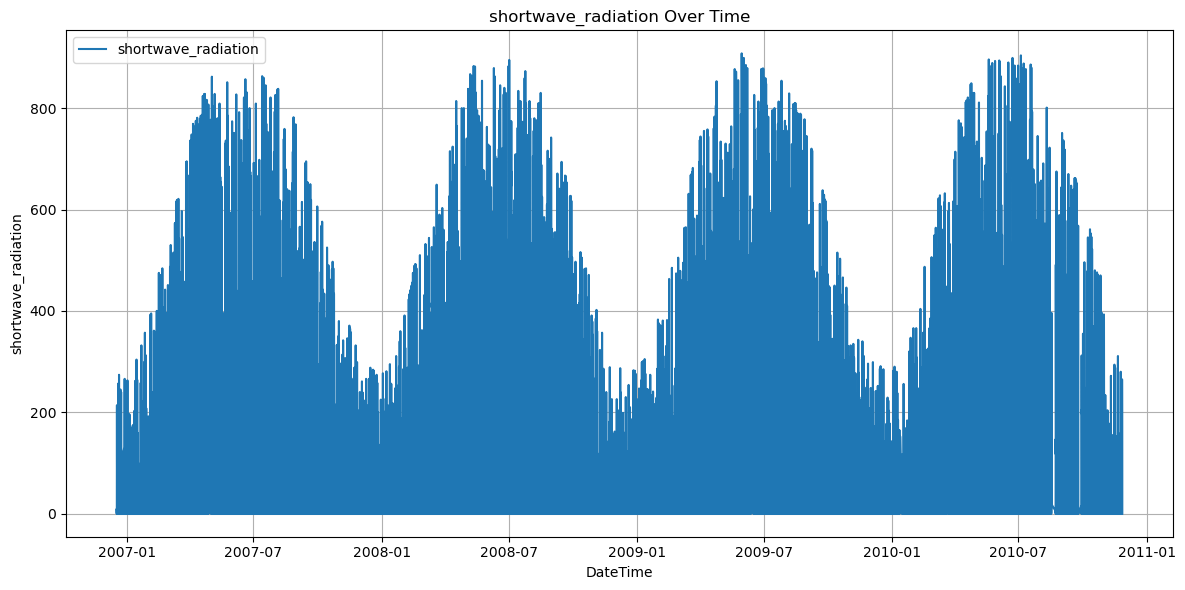

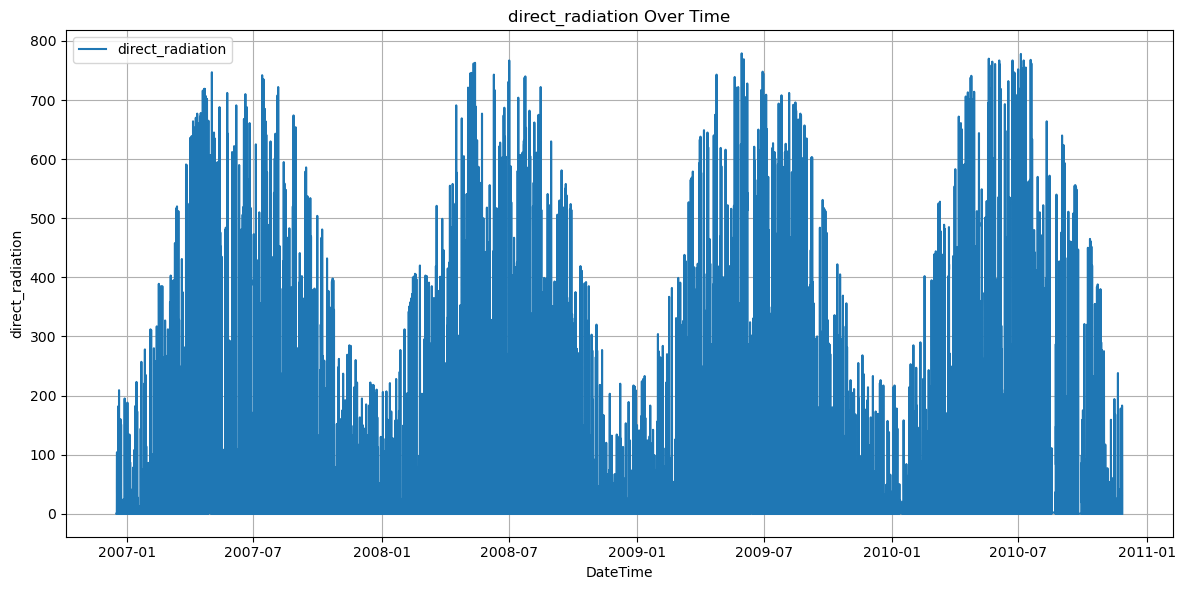

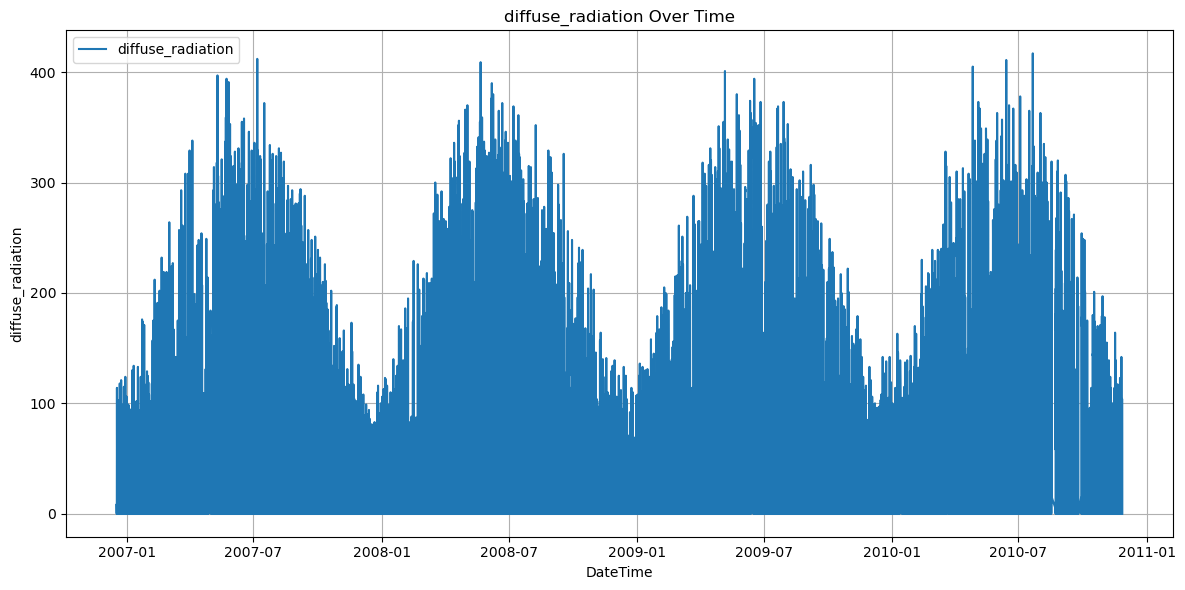

In [22]:
#Lets plot the time series data for each of the features
for col in power_df_clean.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(power_df_clean.index, power_df_clean[col], label=col)
    plt.title(f'{col} Over Time')
    plt.xlabel('DateTime')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

Through the above plots we can visualize that there is a lot of noise in this time series data in our upcoming preprocessing step we might need to  consider some smoothening. E.g moving averages
Also, we can see that the data is not stationary, and there are trends and seasonality in the data, this will also be looked at in the preproceesing and feature engineering steps in future

# Next Steps: Pre-Processing <a class="anchor" id="eda"></a>
---

**Data processing**: Need to make sure the data is smoother, will look at daily, monthly averages to better smoother the data

**Feature engineering**: Selecting the valuable fetures from the dataset and dropping some of the unrelated features from weather data, along with creating some features to make the modelling steps much easier
